In [1]:
# Import foundation
import os, signal, sys, time

sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from IPython import display
from utils import plotting  # plotting utilities for visualizing env. state

In [3]:
env_config = {
    # ===== SCENARIO CLASS =====
    'scenario_name': 'layout_from_file/simple_wood_and_stone',

    # ===== COMPONENTS =====
    'components': [
        # (1) Building houses (REQUIRES payment when using fixed_four_skill_and_loc=True)
        ('Build', {
            'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
            'skill_dist': "pareto",             # <-- REQUIRED
            'payment_max_skill_multiplier': 3   # good
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {'max_num_orders': 5}),
        # (3) Movement and resource collection
        ('Gather', {}),
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,  # <-- works only if Build.payment is set as above

    # ===== STANDARD ARGUMENTS ======
    'n_agents': 4,
    'world_size': [25, 25],
    'episode_length': 1000,

    # multi-action mode (optional; leaving your choices)
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,

    # flattening options (fine as-is)
    'flatten_observations': False,
    'flatten_masks': True,
}

In [4]:
# Define the configuration of the environment that will be built

env_config_planner = {
    # ===== SCENARIO CLASS =====
    # Which Scenario class to use: the class's name in the Scenario Registry (foundation.scenarios).
    # The environment object will be an instance of the Scenario class.
    'scenario_name': 'layout_from_file/simple_wood_and_stone',
    
    # ===== COMPONENTS =====
    # Which components to use (specified as list of ("component_name", {component_kwargs}) tuples).
    #     "component_name" refers to the Component class's name in the Component Registry (foundation.components)
    #     {component_kwargs} is a dictionary of kwargs passed to the Component class
    # The order in which components reset, step, and generate obs follows their listed order below.


    'components': [
        # (1) Building houses
        # OLD: 
        ('Build', dict(skill_dist="pareto", payment_max_skill_multiplier=3)),
        # ('Build', {
        #     'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
        #     'skill_dist': "pareto",             # <-- REQUIRED
        #     'payment_max_skill_multiplier': 3   # good
        # }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', dict(max_num_orders=5)),
        # (3) Movement and resource collection
        ('Gather', dict()),
        # (4) Income tax & lump-sum redistribution
        ('PeriodicBracketTax', dict(bracket_spacing="us-federal", period=10)) #set period=100 when running real sim
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    # (optional) kwargs that are added by the Scenario class (i.e. not defined in BaseEnvironment)
    'env_layout_file': "quadrant_25x25_20each_30clump.txt",
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,
    
    # ===== STANDARD ARGUMENTS ======
    # kwargs that are used by every Scenario class (i.e. defined in BaseEnvironment)
    'n_agents': 4,          # Number of non-planner agents (must be >1)
    'world_size': [25, 25], # [Height, Width] of the env world
    'episode_length': 1000, # Number of timesteps per episode (UPDATED)
    
    # In multi-action-mode, the policy selects an action for each action subspace (defined in component code).
    # Otherwise, the policy selects only 1 action.
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,
    
    # When flattening observations, concatenate scalar & vector observations before output.
    # Otherwise, return observations with minimal processing.
    'flatten_observations': False,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': False, #this is set for dimentions to match 
}

In [5]:
env_config_big = {
    'scenario_name': 'custom/layout_with_starts',
    
    'components': [
        # (1) Building houses
        # OLD: 
        ('Build', dict(skill_dist="pareto", payment_max_skill_multiplier=3)),
        # ('Build', {
        #     'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
        #     'skill_dist': "pareto",             # <-- REQUIRED
        #     'payment_max_skill_multiplier': 3   # good
        # }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', dict(max_num_orders=5)),
        # (3) Movement and resource collection
        ('Gather', dict()),
        # (4) Income tax & lump-sum redistribution
        ('PeriodicBracketTax', dict(bracket_spacing="us-federal", period=10)) #set period=100 when running real sim
    ],

    'n_agents': 8,
    'world_size': [100, 50],
    'episode_length': 1000,
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,
    'flatten_observations': False,
    'flatten_masks': False,

    # Layout controls
    'env_layout_file': 'map_100x50_water_gaps_1p5_wood_1p_stone.txt',
    'fixed_four_skill_and_loc': False,
    'starting_agent_coin': 10,

    # Logging
    'dense_log_frequency': 1,

    #staring locations
    'agent_start_locs': [(10,10), (10,40), (80,10), (80,40), (20,20), (20,30), (70,20), (70,30)],
}

env_b = foundation.make_env_instance(**env_config_big)
env_b.reset()


{'0': {'world-map': array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
  
         [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0.,

In [6]:
env_config_n = {
    'scenario_name': 'custom/layout_with_starts',
    'components': [
        ('Build', {'skill_dist':'pareto', 'payment_max_skill_multiplier':3}),
        ('ContinuousDoubleAuction', {'max_num_orders':5}),
        ('Gather', {}),
    ],
    'n_agents': 8,
    'world_size': [100, 50],
    'episode_length': 1000,
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,
    'flatten_observations': False,
    'flatten_masks': False,

    # Layout controls
    'env_layout_file': 'map_100x50_water_gaps_1p5_wood_1p_stone.txt',
    'fixed_four_skill_and_loc': False,
    'starting_agent_coin': 10,

    # Logging
    'dense_log_frequency': 1,

    #staring locations
    'agent_start_locs': [(10,10), (10,40), (80,10), (80,40), (20,20), (20,30), (70,20), (70,30)],
}

env_n = foundation.make_env_instance(**env_config_n)
env_n.reset()

{'0': {'world-map': array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
  
         [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0.,

In [7]:
env_p = foundation.make_env_instance(**env_config_planner)
obs = env_p.reset()

In [8]:
env_p.world.planner.action_dim

{'PeriodicBracketTax.TaxIndexBracket_000': 22,
 'PeriodicBracketTax.TaxIndexBracket_009': 22,
 'PeriodicBracketTax.TaxIndexBracket_039': 22,
 'PeriodicBracketTax.TaxIndexBracket_084': 22,
 'PeriodicBracketTax.TaxIndexBracket_160': 22,
 'PeriodicBracketTax.TaxIndexBracket_204': 22,
 'PeriodicBracketTax.TaxIndexBracket_510': 22}

In [9]:
import numpy as np

def _to_prob_vector(mask_like, n_expected=None):
    """Return a valid probability vector from list/array mask; fallback to uniform."""
    if mask_like is None:
        if n_expected is None:
            return None
        return np.ones(n_expected) / n_expected

    m = np.asarray(mask_like, dtype=float)
    if m.ndim != 1:
        m = m.ravel()
    s = m.sum()
    if not np.isfinite(s) or s <= 0:
        if n_expected is None:
            n_expected = len(m)
        return np.ones(n_expected) / n_expected

    if (n_expected is not None) and (len(m) != n_expected):
        # If lengths mismatch, fall back to uniform of expected size
        return np.ones(n_expected) / n_expected

    return m / s


def _flatten_submasks_in_order(agent, mask_dict_or_list):
    """
    Flatten a dict/list of sub-masks into one 1-D mask aligned with the
    agent's concatenated action space (order must match the agent).
    """
    parts = []

    # Preferred order: agent._action_names if present
    order = getattr(agent, "_action_names", None)

    if isinstance(mask_dict_or_list, dict):
        if order is None:
            # Stable iteration order if _action_names unavailable
            order = list(mask_dict_or_list.keys())
        for name in order:
            sub = mask_dict_or_list.get(name, None)
            if sub is None:
                # If a subspace missing, infer size from action_dim if possible
                n = None
                if isinstance(getattr(agent, "action_dim", None), dict):
                    n = agent.action_dim.get(name, None)
                parts.append(np.ones(n if n else 1, dtype=float))
            else:
                parts.append(np.asarray(sub, dtype=float).ravel())

    elif isinstance(mask_dict_or_list, list):
        # Assume the list order already matches concatenation order
        for sub in mask_dict_or_list:
            parts.append(np.asarray(sub, dtype=float).ravel())
    else:
        # Already a 1-D mask
        return np.asarray(mask_dict_or_list, dtype=float).ravel()

    if not parts:
        return None
    return np.concatenate(parts, axis=0)


def sample_random_action(agent, mask):
    """
    Correctly sample one action for workers and a list of actions for the planner.
    """
    # ---- Planner: multi-action → dict of sub-masks ----
    if isinstance(mask, dict):
        actions = []
        # Use agent.action_dim order to align with subspaces
        for name, n in agent.action_dim.items():
            sub = mask.get(name, None)
            probs = _to_prob_vector(sub, n_expected=n)
            actions.append(int(np.random.choice(n, p=probs)))
        return actions

    # ---- Worker: list of sub-masks → flatten to one mask → one int ----
    if isinstance(mask, list):
        flat = _flatten_submasks_in_order(agent, mask)
        n = getattr(agent, "_unique_actions", len(flat) if flat is not None else None)
        probs = _to_prob_vector(flat, n_expected=n)
        return int(np.random.choice(len(probs), p=probs))

    # ---- Worker: single 1-D mask or None ----
    probs = _to_prob_vector(mask)
    if probs is None:
        # no mask → choose NO-OP if possible
        return 0
    return int(np.random.choice(len(probs), p=probs))


def sample_random_actions(env, obs):
    """
    Build a valid action dict for all agents in obs:
      - planner gets a list per bracket (multi-action)
      - workers get a single int (combined action)
    """
    actions = {}
    for a_idx, a_obs in obs.items():
        if a_idx not in env._agent_lookup:
            continue
        agent = env.get_agent(a_idx)
        m = a_obs.get("action_mask", None)
        act = sample_random_action(agent, m)

        # Guard: workers must receive ints even if mask looked dict-like
        if not agent.multi_action_mode and isinstance(act, list):
            # Emergency flatten (uniform) if something still went wrong
            n = getattr(agent, "_unique_actions", None)
            if n is None:
                act = 0
            else:
                act = int(np.random.choice(n))
        actions[a_idx] = act
    return actions

In [10]:
from ai_economist import foundation
import numpy as np


done = {"__all__": False}

# --- Run a full episode ---
while not done["__all__"]:

    actions = {}

    # --- Worker actions (NO-OP = 0 for now) ---
    for a in env_p.world.agents:
        actions[str(a.idx)] = 0

    # --- Planner actions (multi-action mode) ---
    planner = env_p.world.planner
    p_id = planner.idx

    if planner.multi_action_mode:
        # Number of tax brackets (action subspaces)
        n_brackets = len(planner.action_dim)

        # Choose some NON-zero actions here (1..n_disc_rates)
        # Example: choose the middle tax index for all brackets
        actions[p_id] = [1] * n_brackets     # <-- planner is now active
    else:
        actions[p_id] = 0

    # --- Step environment ---
    obs, rew, done, info = env_p.step(actions)

In [11]:
p = env_p.world.planner
print("Planner action_dim:", p.action_dim)                  # dict of 7 -> 22
print("Example planner mask type:", type(obs[p.idx]["action_mask"]))
if isinstance(obs[p.idx]["action_mask"], dict):
    for k,v in obs[p.idx]["action_mask"].items():
        print(" ", k, type(v), len(v), "sum", np.asarray(v).sum())

Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
Example planner mask type: <class 'dict'>
  PeriodicBracketTax.TaxIndexBracket_000 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_009 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_039 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_084 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_160 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_204 <class 'list'> 21 sum 21
  PeriodicBracketTax.TaxIndexBracket_510 <class 'list'> 21 sum 21


In [12]:
planner = env_p.get_agent(agent_idx='p') # The planner agent
planner.action_dim

{'PeriodicBracketTax.TaxIndexBracket_000': 22,
 'PeriodicBracketTax.TaxIndexBracket_009': 22,
 'PeriodicBracketTax.TaxIndexBracket_039': 22,
 'PeriodicBracketTax.TaxIndexBracket_084': 22,
 'PeriodicBracketTax.TaxIndexBracket_160': 22,
 'PeriodicBracketTax.TaxIndexBracket_204': 22,
 'PeriodicBracketTax.TaxIndexBracket_510': 22}

In [13]:
metrics = env_p.get_current_optimization_metrics()
metrics

{0: np.float64(6.3486189007219345),
 1: np.float64(6.3486189007219345),
 2: np.float64(4.878618900721935),
 3: np.float64(3.1986189007219346),
 'p': np.float64(10.0)}

In [14]:
print("timestep =", env_p.world.timestep)

timestep = 1000


In [15]:
from ai_economist import foundation

num_episodes = 100          # total number of episodes to run
print_every = 10            # print metrics every N episodes

for ep in range(1, num_episodes + 1):

    # --- create fresh env ---
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}

    # --- run episode (NO-OP policy, replace if you have agents) ---
    while not done["__all__"]:
        actions = {}

        # worker actions (0 = no-op)
        for a in env.world.agents:
            actions[str(a.idx)] = 0

        # planner action (multi-action → list of zeros)
        if env.world.planner.multi_action_mode:
            n = len(env.world.planner.action_dim)
            actions[env.world.planner.idx] = [0] * n
        else:
            actions[env.world.planner.idx] = 0

        obs, rew, done, info = env.step(actions)

    # --- END OF EPISODE: compute metrics ---
    metrics = env.get_current_optimization_metrics()

    # --- PRINT EVERY 100 EPISODES ---
    if ep % print_every == 0:
        print(f"\n=== Episode {ep} ===")
        for agent_id, val in metrics.items():
            print(f"Agent {agent_id}: {val}")


=== Episode 10 ===
Agent 0: 4.038618900721934
Agent 1: 3.6186189007219345
Agent 2: 6.3486189007219345
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 20 ===
Agent 0: 4.458618900721935
Agent 1: 6.3486189007219345
Agent 2: 4.458618900721935
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 30 ===
Agent 0: 4.038618900721934
Agent 1: 6.3486189007219345
Agent 2: 4.038618900721934
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 40 ===
Agent 0: 6.3486189007219345
Agent 1: 3.4086189007219345
Agent 2: 6.3486189007219345
Agent 3: 4.878618900721935
Agent p: 10.0

=== Episode 50 ===
Agent 0: 6.3486189007219345
Agent 1: 3.6186189007219345
Agent 2: 3.4086189007219345
Agent 3: 6.3486189007219345
Agent p: 10.0

=== Episode 60 ===
Agent 0: 6.3486189007219345
Agent 1: 3.8286189007219344
Agent 2: 6.3486189007219345
Agent 3: 3.8286189007219344
Agent p: 10.0

=== Episode 70 ===
Agent 0: 3.1986189007219346
Agent 1: 4.878618900721935
Agent 2: 6.3486189007219345
Agent 3: 6.3486189007219345

In [16]:
# Grab the tax component and call its metrics method
tax_comp = env_p.get_component("PeriodicBracketTax")   # name of the component class
tax_metrics_now = tax_comp.get_metrics()
tax_metrics_now

{'avg_bracket_rate/000': np.float64(0.0),
 'bracket_occupancy/000': np.float64(1.0),
 'avg_bracket_rate/009': np.float64(0.0),
 'bracket_occupancy/009': np.float64(0.0),
 'avg_bracket_rate/039': np.float64(0.0),
 'bracket_occupancy/039': np.float64(0.0),
 'avg_bracket_rate/084': np.float64(0.0),
 'bracket_occupancy/084': np.float64(0.0),
 'avg_bracket_rate/160': np.float64(0.0),
 'bracket_occupancy/160': np.float64(0.0),
 'avg_bracket_rate/204': np.float64(0.0),
 'bracket_occupancy/204': np.float64(0.0),
 'avg_bracket_rate/510': np.float64(0.0),
 'bracket_occupancy/510': np.float64(0.0),
 'avg_effective_tax_rate': np.float64(0.0),
 'total_collected_taxes': 0.0,
 'avg_tax_rate/poorest': np.float64(0.0),
 'avg_tax_rate/richest': np.float64(0.0)}

In [17]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

In [18]:
from ai_economist import foundation

num_episodes = 100
print_every = 10

for ep in range(1, num_episodes + 1):
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}
    while not done["__all__"]:
        actions = {}

        # Workers: NO-OP (0). Replace with your policy if you have one.
        for a in env.world.agents:
            actions[str(a.idx)] = 0

        # Planner: multi-action → list of zeros; otherwise 0
        p = env.world.planner
        if p.multi_action_mode:
            actions[p.idx] = [0] * len(p.action_dim)
        else:
            actions[p.idx] = 0

        obs, rew, done, info = env.step(actions)

    # At the end of the episode, get tax metrics
    tax_comp = env.get_component("PeriodicBracketTax")
    tax_metrics = tax_comp.get_metrics()

    if ep % print_every == 0:
        print(f"\n=== Episode {ep} — PeriodicBracketTax.get_metrics() ===")
        for k, v in tax_metrics.items():
            print(f"{k}: {v}")


=== Episode 10 — PeriodicBracketTax.get_metrics() ===
avg_bracket_rate/000: 0.0
bracket_occupancy/000: 1.0
avg_bracket_rate/009: 0.0
bracket_occupancy/009: 0.0
avg_bracket_rate/039: 0.0
bracket_occupancy/039: 0.0
avg_bracket_rate/084: 0.0
bracket_occupancy/084: 0.0
avg_bracket_rate/160: 0.0
bracket_occupancy/160: 0.0
avg_bracket_rate/204: 0.0
bracket_occupancy/204: 0.0
avg_bracket_rate/510: 0.0
bracket_occupancy/510: 0.0
avg_effective_tax_rate: 0.0
total_collected_taxes: 0.0
avg_tax_rate/poorest: 0.0
avg_tax_rate/richest: 0.0

=== Episode 20 — PeriodicBracketTax.get_metrics() ===
avg_bracket_rate/000: 0.0
bracket_occupancy/000: 1.0
avg_bracket_rate/009: 0.0
bracket_occupancy/009: 0.0
avg_bracket_rate/039: 0.0
bracket_occupancy/039: 0.0
avg_bracket_rate/084: 0.0
bracket_occupancy/084: 0.0
avg_bracket_rate/160: 0.0
bracket_occupancy/160: 0.0
avg_bracket_rate/204: 0.0
bracket_occupancy/204: 0.0
avg_bracket_rate/510: 0.0
bracket_occupancy/510: 0.0
avg_effective_tax_rate: 0.0
total_collect

In [19]:
print("t =", env.world.timestep,
      "tax_cycle_pos =", env.get_component("PeriodicBracketTax").tax_cycle_pos, 
      "planner_action =", actions[p_id])

t = 1000 tax_cycle_pos = 1 planner_action = [0, 0, 0, 0, 0, 0, 0]


In [20]:
tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

{'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.0), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.0), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.0), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.0), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [21]:
for ep in range(100):

    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()
    done = {"__all__": False}

    while not done["__all__"]:

        actions = {}

        for a in env.world.agents:
            actions[str(a.idx)] = 0

        planner = env.world.planner
        n_brackets = len(planner.action_dim)
        actions[planner.idx] = [1] * n_brackets   # or random, or your policy

        obs, rew, done, info = env.step(actions)

    print("EP", ep, "TAX METRICS:", env.get_component("PeriodicBracketTax").get_metrics())

EP 0 TAX METRICS: {'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.0), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.0), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.0), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.0), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}
EP 1 TAX METRICS: {'avg_bracket_rate/000': np.float64(0.0), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.0), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.0), 'bracket_occupancy/

In [22]:
import pandas as pd

num_episodes = 30
rows = []

for ep in range(1, num_episodes + 1):
    env = foundation.make_env_instance(**env_config_planner)
    obs = env.reset()

    done = {"__all__": False}
    while not done["__all__"]:
        actions = {}
        for a in env.world.agents:
            actions[str(a.idx)] = 0
        p = env.world.planner
        actions[p.idx] = [0] * len(p.action_dim) if p.multi_action_mode else 0
        obs, rew, done, info = env.step(actions)

    tax_comp = env.get_component("PeriodicBracketTax")
    m = tax_comp.get_metrics()
    m_row = {"episode": ep}
    m_row.update(m)
    rows.append(m_row)

df_tax = pd.DataFrame(rows)
df_tax.head()

,episode,avg_bracket_rate/000,bracket_occupancy/000,avg_bracket_rate/009,bracket_occupancy/009,avg_bracket_rate/039,bracket_occupancy/039,avg_bracket_rate/084,bracket_occupancy/084,avg_bracket_rate/160,bracket_occupancy/160,avg_bracket_rate/204,bracket_occupancy/204,avg_bracket_rate/510,bracket_occupancy/510,avg_effective_tax_rate,total_collected_taxes,avg_tax_rate/poorest,avg_tax_rate/richest
0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
episode_tax_log = []

env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()
tax_comp = env.get_component("PeriodicBracketTax")

done = {"__all__": False}
while not done["__all__"]:
    actions = {}
    for a in env.world.agents:
        actions[str(a.idx)] = 0
    p = env.world.planner
    actions[p.idx] = [0] * len(p.action_dim) if p.multi_action_mode else 0

    obs, rew, done, info = env.step(actions)

    # OPTIONAL: log metrics, e.g., at tax days or every K steps
    if tax_comp.tax_cycle_pos == 1 or done["__all__"]:
        episode_tax_log.append({
            "t": env.world.timestep,
            **tax_comp.get_metrics()
        })

episode_tax_log[:3]

[{'t': 10,
  'avg_bracket_rate/000': np.float64(0.0),
  'bracket_occupancy/000': np.float64(1.0),
  'avg_bracket_rate/009': np.float64(0.0),
  'bracket_occupancy/009': np.float64(0.0),
  'avg_bracket_rate/039': np.float64(0.0),
  'bracket_occupancy/039': np.float64(0.0),
  'avg_bracket_rate/084': np.float64(0.0),
  'bracket_occupancy/084': np.float64(0.0),
  'avg_bracket_rate/160': np.float64(0.0),
  'bracket_occupancy/160': np.float64(0.0),
  'avg_bracket_rate/204': np.float64(0.0),
  'bracket_occupancy/204': np.float64(0.0),
  'avg_bracket_rate/510': np.float64(0.0),
  'bracket_occupancy/510': np.float64(0.0),
  'avg_effective_tax_rate': np.float64(0.0),
  'total_collected_taxes': 0.0,
  'avg_tax_rate/poorest': np.float64(0.0),
  'avg_tax_rate/richest': np.float64(0.0)},
 {'t': 20,
  'avg_bracket_rate/000': np.float64(0.0),
  'bracket_occupancy/000': np.float64(1.0),
  'avg_bracket_rate/009': np.float64(0.0),
  'bracket_occupancy/009': np.float64(0.0),
  'avg_bracket_rate/039': np.fl

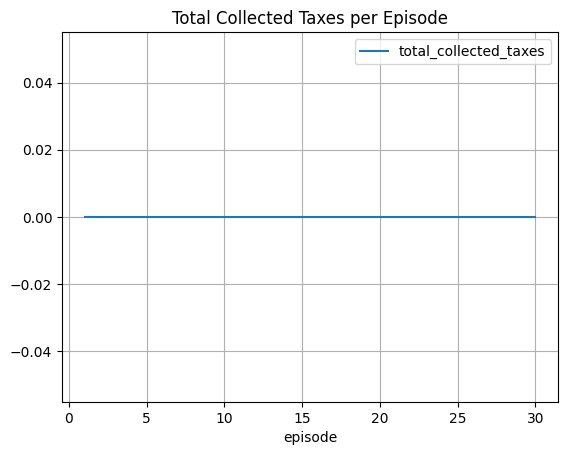

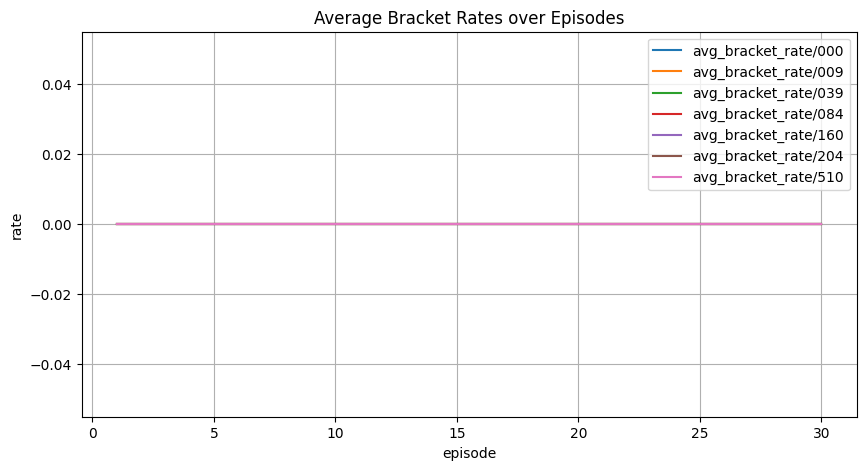

In [24]:
import matplotlib.pyplot as plt

# Example: plot total_collected_taxes across episodes
if "total_collected_taxes" in df_tax.columns:
    df_tax.plot(x="episode", y="total_collected_taxes", title="Total Collected Taxes per Episode", grid=True)

# Example: bracket rates (if present)
br_cols = [c for c in df_tax.columns if c.startswith("avg_bracket_rate/")]
if br_cols:
    plt.figure(figsize=(10,5))
    for c in br_cols:
        plt.plot(df_tax["episode"], df_tax[c], label=c)
    plt.legend()
    plt.grid(True)
    plt.title("Average Bracket Rates over Episodes")
    plt.xlabel("episode")
    plt.ylabel("rate")
    plt.show()

In [25]:


# def sample_random_action(agent, mask):
#     """Sample random UNMASKED action(s) for agent."""
#     # Return a list of actions: 1 for each action subspace
#     if agent.multi_action_mode:
#         split_masks = np.split(mask, agent.action_spaces.cumsum()[:-1])
#         return [np.random.choice(np.arange(len(m_)), p=m_/m_.sum()) for m_ in split_masks]

#     # Return a single action
#     else:
#         return np.random.choice(np.arange(agent.action_spaces), p=mask/mask.sum())

# def sample_random_actions(env, obs):
#     """Samples random UNMASKED actions for each agent in obs."""
        
#     actions = {
#         a_idx: sample_random_action(env.get_agent(a_idx), a_obs['action_mask'])
#         for a_idx, a_obs in obs.items()
#     }

#     return actions






In [26]:
actions = sample_random_actions(env_p, obs)
obs, rew, done, info = env_p.step(actions)

In [27]:
for agent_idx, reward in rew.items(): 
    print("{:2} {:.3f}".format(agent_idx, reward))

0  -0.053
1  -0.053
2  -0.053
3  0.000
p  0.000


In [28]:
def do_plot(env, ax, fig):
    """Plots world state during episode sampling."""
    plotting.plot_env_state(env, ax)
    ax.set_aspect('equal')
    display.display(fig)
    display.clear_output(wait=True)

def play_random_episode(env, plot_every=100, do_dense_logging=False):
    """Plays an episode with randomly sampled actions.
    
    Demonstrates gym-style API:
        obs                  <-- env.reset(...)         # Reset
        obs, rew, done, info <-- env.step(actions, ...) # Interaction loop
    
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Reset
    obs = env.reset(force_dense_logging=do_dense_logging)

    env._world_dense_log_frequency = 1 #NEW

    # Interaction loop (w/ plotting)
    for t in range(env.episode_length):
        actions = sample_random_actions(env, obs)
        obs, rew, done, info = env.step(actions)

        if ((t+1) % plot_every) == 0:
            do_plot(env, ax, fig)

    if ((t+1) % plot_every) != 0:
        do_plot(env, ax, fig)        

In [29]:
planner_obs = obs[env_p.world.planner.idx]
print("Keys in planner obs:", planner_obs.keys())
print("Action mask:", planner_obs.get("action_mask"))

Keys in planner obs: dict_keys(['world-inventory-Coin', 'world-inventory-Stone', 'world-inventory-Wood', 'world-map', 'world-idx_map', 'time', 'ContinuousDoubleAuction-market_rate-Stone', 'ContinuousDoubleAuction-price_history-Stone', 'ContinuousDoubleAuction-full_asks-Stone', 'ContinuousDoubleAuction-full_bids-Stone', 'ContinuousDoubleAuction-market_rate-Wood', 'ContinuousDoubleAuction-price_history-Wood', 'ContinuousDoubleAuction-full_asks-Wood', 'ContinuousDoubleAuction-full_bids-Wood', 'PeriodicBracketTax-is_tax_day', 'PeriodicBracketTax-is_first_day', 'PeriodicBracketTax-tax_phase', 'PeriodicBracketTax-last_incomes', 'PeriodicBracketTax-curr_rates', 'p0', 'p1', 'p2', 'p3', 'action_mask'])
Action mask: {'PeriodicBracketTax.TaxIndexBracket_000': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'PeriodicBracketTax.TaxIndexBracket_009': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'PeriodicBracketTax.TaxIndexBracket_039': [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [30]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

done = {"__all__": False}

while not done["__all__"]:
    actions = {}

    # workers do nothing
    for a in env.world.agents:
        actions[str(a.idx)] = 0

    # planner: choose a mid-level rate for all 7 brackets
    p = env.world.planner
    n_brackets = len(p.action_dim)
    actions[p.idx] = [5] * n_brackets

    obs, rew, done, info = env.step(actions)

In [31]:
tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

{'avg_bracket_rate/000': np.float64(0.19999999999999996), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.19999999999999996), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.19999999999999996), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.19999999999999996), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.19999999999999996), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.19999999999999996), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.19999999999999996), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [32]:
env = foundation.make_env_instance(**env_config_planner)
obs = env.reset()

done = {"__all__": False}

while not done["__all__"]:

    actions = {}

    # Let workers move & gather randomly
    for a in env.world.agents:
        actions[str(a.idx)] = np.random.randint(0, 7)

    # Planner: set bracket rate for each bracket
    p = env.world.planner
    n_brackets = len(p.action_dim)
    actions[p.idx] = [5] * n_brackets

    obs, rew, done, info = env.step(actions)

tax_comp = env.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

{'avg_bracket_rate/000': np.float64(0.19999999999999996), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.19999999999999996), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.19999999999999996), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.19999999999999996), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.19999999999999996), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.19999999999999996), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.19999999999999996), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [33]:
metrics = env.get_current_optimization_metrics()
metrics

{0: np.float64(-0.4238810992780655),
 1: np.float64(-1.0538810992780654),
 2: np.float64(1.1511189007219347),
 3: np.float64(1.0986189007219345),
 'p': np.float64(10.0)}

In [34]:
env_config = {
    # ===== SCENARIO CLASS =====
    'scenario_name': 'layout_from_file/simple_wood_and_stone',

    # ===== COMPONENTS =====
    'components': [
        # (1) Building houses (REQUIRES payment when using fixed_four_skill_and_loc=True)
        ('Build', {
            'payment': 10.0,                    # <-- REQUIRED for LayoutFromFile fixed_four_skill_and_loc
            'skill_dist': "pareto",             # <-- REQUIRED
            'payment_max_skill_multiplier': 3   # good
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {'max_num_orders': 5}),
        # (3) Movement and resource collection
        ('Gather', {}),
    ],

    # ===== SCENARIO CLASS ARGUMENTS =====
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,  # <-- works only if Build.payment is set as above

    # ===== STANDARD ARGUMENTS ======
    'n_agents': 4,
    'world_size': [25, 25],
    'episode_length': 1000,

    # multi-action mode (optional; leaving your choices)
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,

    # flattening options (fine as-is)
    'flatten_observations': False,
    'flatten_masks': True,
}

env = foundation.make_env_instance(**env_config)

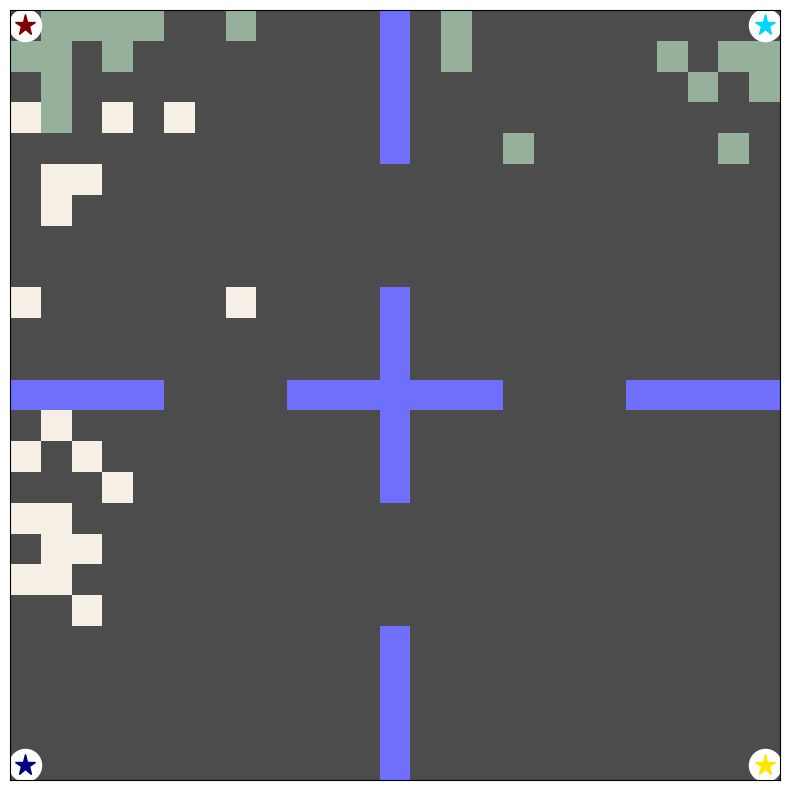

In [35]:
play_random_episode(env_p, plot_every=100)

There are a few additional details worth pointing out:
- Worker agents get to see the taxes that will affect them through the observations generated by the component (```generate_observations```).
- The planner is forced to take the NO-OP action on all timesteps except those at the start of each tax period (```generate_masks```).

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Cost (Stone)   :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   

Income (Wood)  :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Stone) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Build) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   


((<Figure size 1600x300 with 5 Axes>,
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1600x800 with 8 Axes>),
 {'Sell Stone': [0, 0, 0, 0],
  'Buy Stone': [0, 0, 0, 0],
  'Sell Wood': [0, 0, 0, 0],
  'Buy Wood': [0, 0, 0, 0],
  'Build': [0, 0, 0, 0],
  'Total': array([0, 0, 0, 0])},
 [10, 10, 10, 10],
 {'Stone': [], 'Wood': []},
 [])

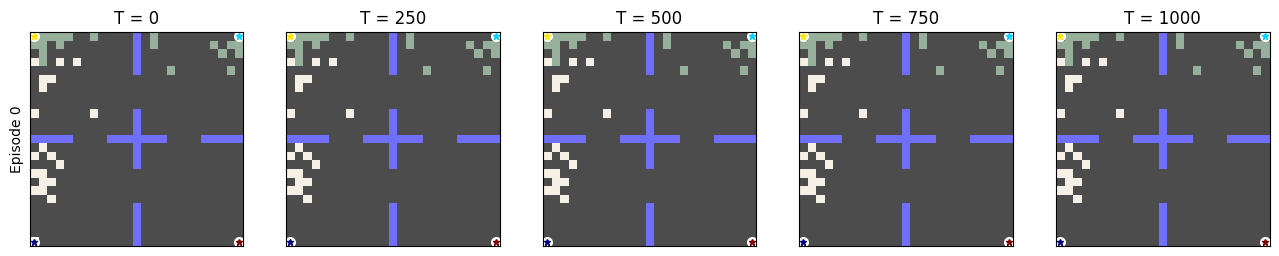

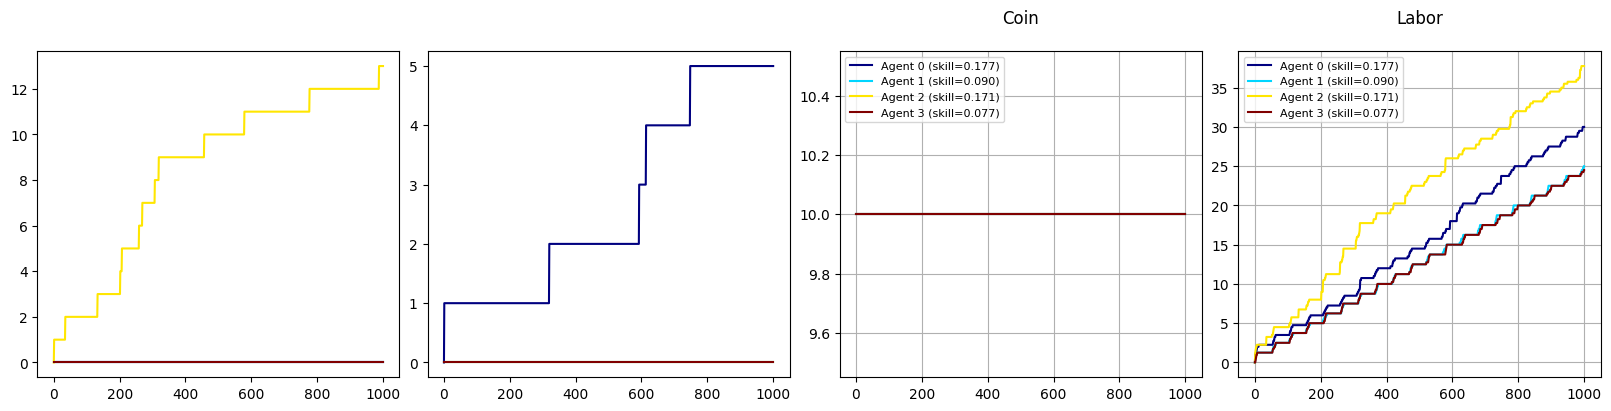

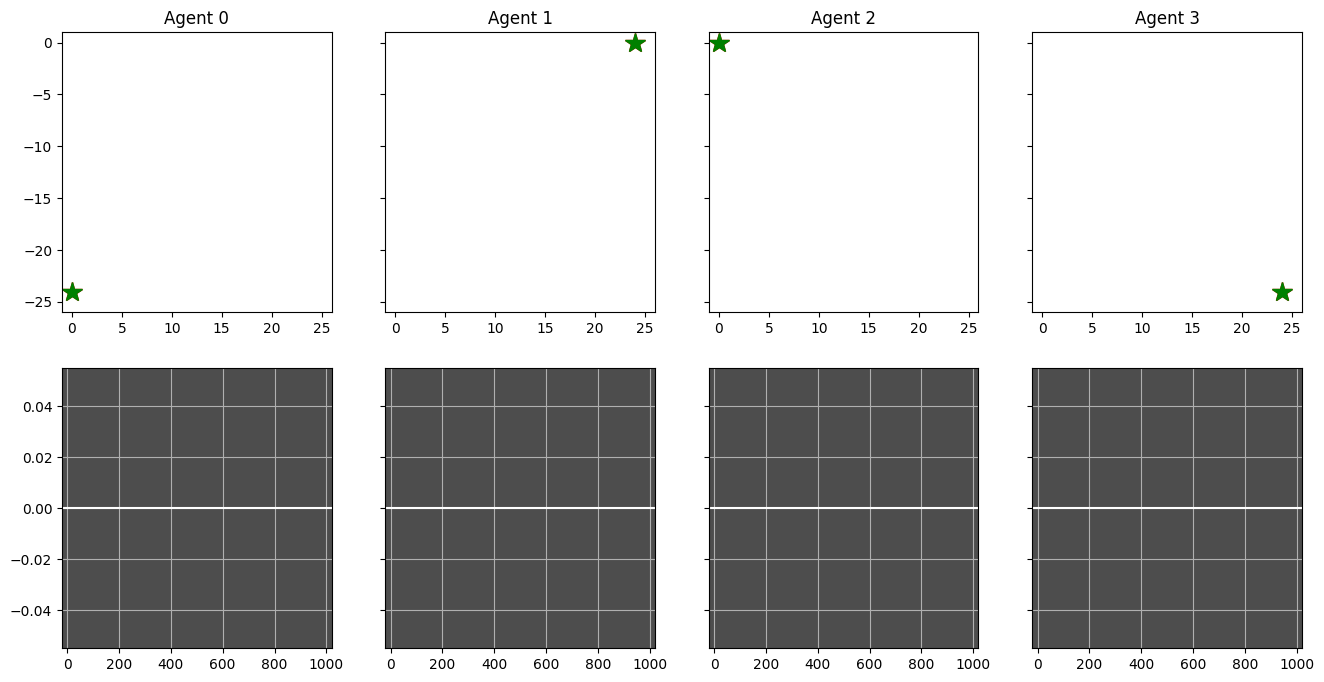

In [36]:
env_ = foundation.make_env_instance(**env_config_planner)
obs = env_p.reset()

obs = env_p.reset(force_dense_logging=True)

for t in range(env_p.episode_length):
    actions = sample_random_actions(env_p, obs)
    obs, rew, done, info = env_p.step(actions)

dense_log = env_p.previous_episode_dense_log

plotting.breakdown(dense_log)

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Cost (Stone)   :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   

Income (Wood)  :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Stone) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Build) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   


((<Figure size 1600x300 with 5 Axes>,
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1600x800 with 16 Axes>),
 {'Sell Stone': [0, 0, 0, 0, 0, 0, 0, 0],
  'Buy Stone': [0, 0, 0, 0, 0, 0, 0, 0],
  'Sell Wood': [0, 0, 0, 0, 0, 0, 0, 0],
  'Buy Wood': [0, 0, 0, 0, 0, 0, 0, 0],
  'Build': [0, 0, 0, 0, 0, 0, 0, 0],
  'Total': array([0, 0, 0, 0, 0, 0, 0, 0])},
 [10, 10, 10, 10, 10, 10, 10, 10],
 {'Stone': [], 'Wood': []},
 [])

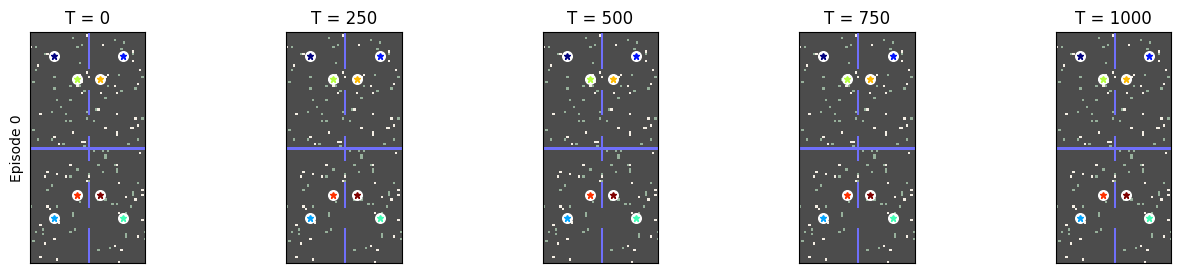

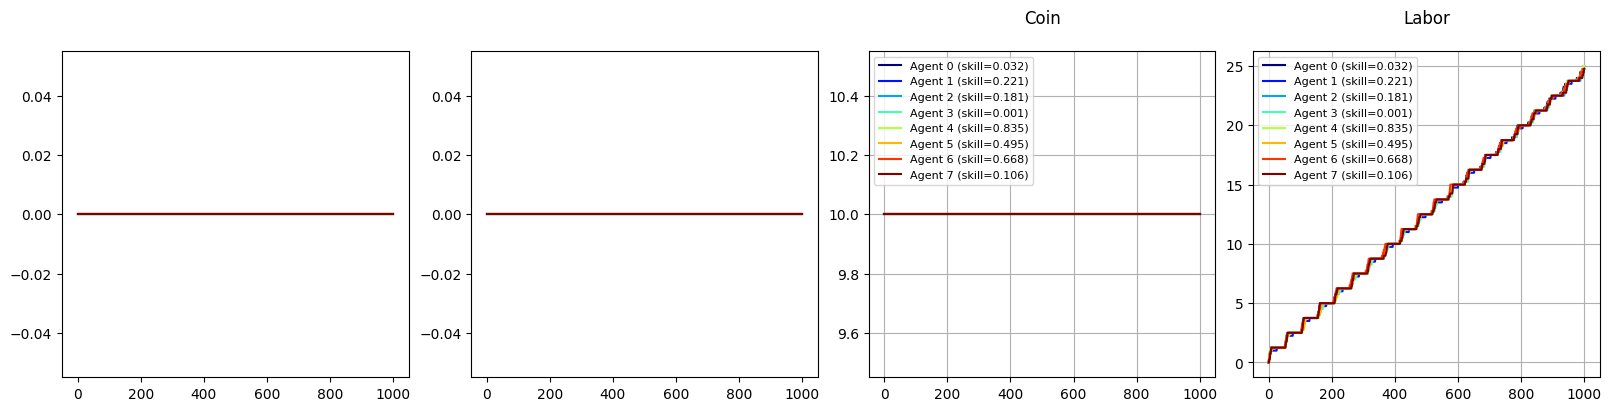

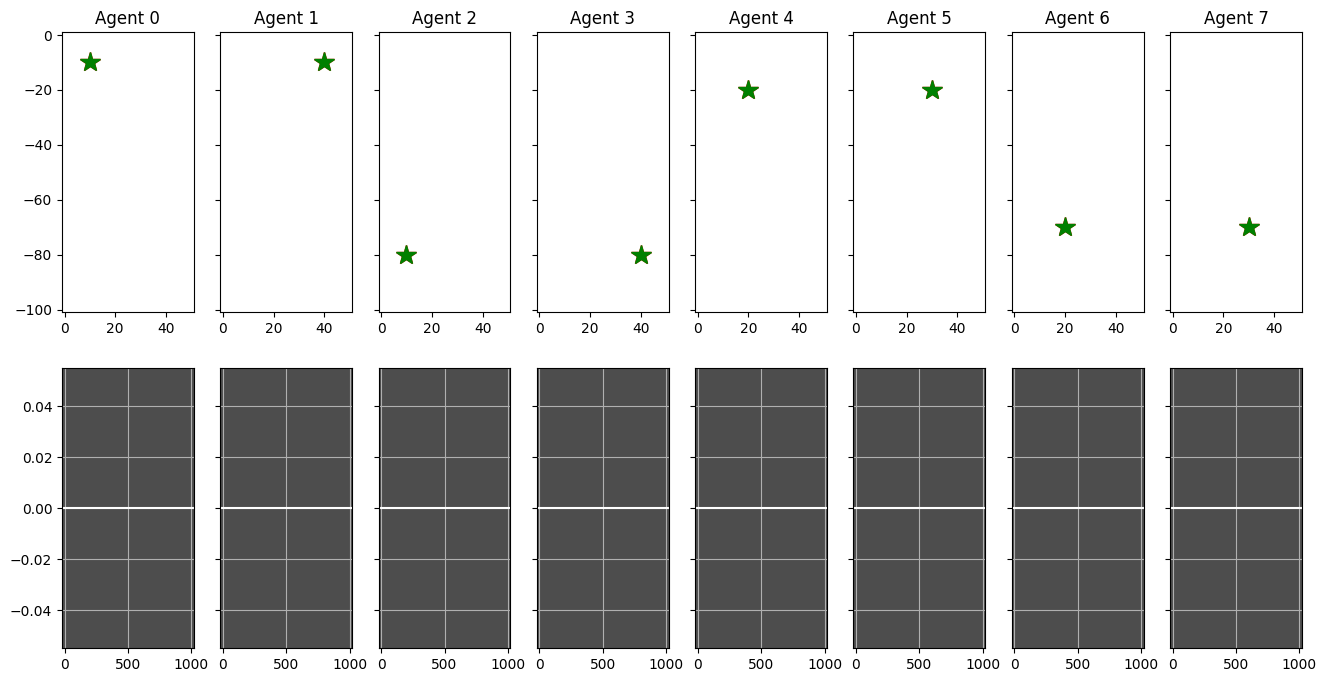

In [37]:
#env_b = foundation.make_env_instance(**env_config_big)
#obs = env_b.reset()

obs = env_n.reset(force_dense_logging=True)

for t in range(env_n.episode_length):
    actions = sample_random_actions(env_n, obs)
    obs, rew, done, info = env_n.step(actions)

dense_log = env_n.previous_episode_dense_log

plotting.breakdown(dense_log)

# Debugging


In [38]:
agent0 = env_p.get_agent("0")
print("Unique actions:", agent0._unique_actions)
print("Action names:", agent0._action_names)
print("Action spaces:", agent0.action_spaces)
print("Action dim:", agent0.action_dim)
#print("Flatten masks:", env_p.flatten_masks)
print("Multi-action mode (workers):", agent0.multi_action_mode)
print("Worker action_mask sample:", obs["0"]["action_mask"])

Unique actions: 6
Action names: ['Build', 'ContinuousDoubleAuction.Buy_Stone', 'ContinuousDoubleAuction.Sell_Stone', 'ContinuousDoubleAuction.Buy_Wood', 'ContinuousDoubleAuction.Sell_Wood', 'Gather']
Action spaces: 50
Action dim: {'Build': 1, 'ContinuousDoubleAuction.Buy_Stone': 11, 'ContinuousDoubleAuction.Sell_Stone': 11, 'ContinuousDoubleAuction.Buy_Wood': 11, 'ContinuousDoubleAuction.Sell_Wood': 11, 'Gather': 4}
Multi-action mode (workers): False
Worker action_mask sample: {'Build': [0], 'ContinuousDoubleAuction.Sell_Stone': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'ContinuousDoubleAuction.Buy_Stone': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'ContinuousDoubleAuction.Sell_Wood': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'ContinuousDoubleAuction.Buy_Wood': [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], 'Gather': [1, 1, 1, 1]}


In [39]:
print("Agent0 action_names:", agent0._action_names)
print("Agent0 action_spaces:", agent0.action_spaces)
print("Gather sub-mask:", obs["0"]["action_mask"]["Gather"])
print("CDA.Buy_Wood mask:", obs["0"]["action_mask"]["ContinuousDoubleAuction.Buy_Wood"])

Agent0 action_names: ['Build', 'ContinuousDoubleAuction.Buy_Stone', 'ContinuousDoubleAuction.Sell_Stone', 'ContinuousDoubleAuction.Buy_Wood', 'ContinuousDoubleAuction.Sell_Wood', 'Gather']
Agent0 action_spaces: 50
Gather sub-mask: [1, 1, 1, 1]
CDA.Buy_Wood mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


In [40]:

agent0 = env_p.get_agent("0")
print(agent0.single_action_map)

{1: ['Build', 1], 2: ['ContinuousDoubleAuction.Buy_Stone', 1], 3: ['ContinuousDoubleAuction.Buy_Stone', 2], 4: ['ContinuousDoubleAuction.Buy_Stone', 3], 5: ['ContinuousDoubleAuction.Buy_Stone', 4], 6: ['ContinuousDoubleAuction.Buy_Stone', 5], 7: ['ContinuousDoubleAuction.Buy_Stone', 6], 8: ['ContinuousDoubleAuction.Buy_Stone', 7], 9: ['ContinuousDoubleAuction.Buy_Stone', 8], 10: ['ContinuousDoubleAuction.Buy_Stone', 9], 11: ['ContinuousDoubleAuction.Buy_Stone', 10], 12: ['ContinuousDoubleAuction.Buy_Stone', 11], 13: ['ContinuousDoubleAuction.Sell_Stone', 1], 14: ['ContinuousDoubleAuction.Sell_Stone', 2], 15: ['ContinuousDoubleAuction.Sell_Stone', 3], 16: ['ContinuousDoubleAuction.Sell_Stone', 4], 17: ['ContinuousDoubleAuction.Sell_Stone', 5], 18: ['ContinuousDoubleAuction.Sell_Stone', 6], 19: ['ContinuousDoubleAuction.Sell_Stone', 7], 20: ['ContinuousDoubleAuction.Sell_Stone', 8], 21: ['ContinuousDoubleAuction.Sell_Stone', 9], 22: ['ContinuousDoubleAuction.Sell_Stone', 10], 23: ['Conti

In [41]:
import numpy as np

def _probs_from_mask_1d(mask_1d, expected_len=None):
    """Turn a 1-D list/array mask into a probability vector. Uniform fallback if all-zero or len mismatch."""
    m = np.asarray(mask_1d, dtype=float).ravel()
    if expected_len is not None and len(m) != expected_len:
        # length mismatch -> fallback uniform of expected_len
        return np.ones(expected_len, dtype=float) / float(expected_len)
    s = m.sum()
    if not np.isfinite(s) or s <= 0:
        return np.ones_like(m, dtype=float) / float(len(m))
    return m / s


def _flatten_worker_mask(agent, mask_dict):
    """
    Use agent.flatten_masks() to produce the correct single-action mask:
    [no-op] + Build + CDA.Buy_Stone + CDA.Sell_Stone + CDA.Buy_Wood + CDA.Sell_Wood + Gather
    Returns a 1-D vector of length agent.action_spaces (e.g., 50).
    """
    # agent.flatten_masks handles NO-OP and subspace ordering correctly
    flat = agent.flatten_masks(mask_dict)
    # Safety: ensure length matches action_spaces
    n = int(agent.action_spaces)  # e.g., 50
    flat = np.asarray(flat, dtype=float).ravel()
    if len(flat) != n:
        # fallback to uniform if anything goes wrong
        return np.ones(n, dtype=float) / float(n)
    return flat


def sample_worker_action(agent, obs_mask):
    """
    Workers are single-action agents (multi_action_mode=False):
      - Expect ONE integer in [0 .. agent.action_spaces-1]
      - obs_mask is a dict of sub-masks; flatten via agent.flatten_masks()
    """
    if isinstance(obs_mask, dict):
        flat = _flatten_worker_mask(agent, obs_mask)
        probs = _probs_from_mask_1d(flat, expected_len=len(flat))
        return int(np.random.choice(len(probs), p=probs))
    elif isinstance(obs_mask, (list, np.ndarray)):
        # If you ever get a list of sub-masks instead of dict (rare in your setup)
        m = np.asarray(obs_mask, dtype=float)
        if m.ndim > 1:
            m = m.ravel()
        probs = _probs_from_mask_1d(m)
        return int(np.random.choice(len(probs), p=probs))
    else:
        # No mask -> NO-OP
        return 0


def sample_planner_action(agent, obs_mask, tax_cycle_pos=None):
    """
    Planner is multi-action (multi_action_mode=True):
      - Must return a LIST with one integer per subspace (e.g., 7 brackets)
      - Each subspace index is in [0..N] where 0 is subspace NO-OP.
      - obs_mask is a dict of subspace masks, length N each (no NO-OP inside).
      - On non-tax days, component supplies all-zero masks; return all zeros.
    """
    # Non-tax day (or no masks) -> all NO-OPs
    if not isinstance(obs_mask, dict):
        return [0] * len(agent.action_dim)

    # If all sub-masks are all-zero, return no-ops
    all_zero = True
    for sub_m in obs_mask.values():
        if np.asarray(sub_m, dtype=float).sum() > 0:
            all_zero = False
            break
    if all_zero:
        return [0] * len(agent.action_dim)

    actions = []
    # Iterate in the agent's subspace order
    for subspace_name, n_with_noop in agent.action_dim.items():
        # sub-mask is length N (no NO-OP), we add NO-OP at index 0 with weight 1.0
        sub_mask = np.asarray(obs_mask.get(subspace_name, []), dtype=float).ravel()
        N = len(sub_mask)

        # Build [NO-OP_prob, sub_mask...] then normalize
        extended = np.concatenate([[1.0], sub_mask])  # allow NO-OP with some probability
        s = extended.sum()
        if s <= 0 or not np.isfinite(s):
            actions.append(0)  # no valid actions -> NO-OP
        else:
            probs = extended / s
            actions.append(int(np.random.choice(len(probs), p=probs)))
    return actions


def sample_random_actions(env, obs):
    """
    Build a valid action dict for all agents:
      - workers (single-action): int in [0..action_spaces-1] (e.g., 0..49)
      - planner (multi-action): list[int] per subspace
    """
    actions = {}
    tax_comp = env.get_component("PeriodicBracketTax")
    tax_cycle_pos = getattr(tax_comp, "tax_cycle_pos", None)

    for a_idx, a_obs in obs.items():
        if a_idx not in env._agent_lookup:
            continue
        agent = env.get_agent(a_idx)
        mask = a_obs.get("action_mask", None)

        if agent.multi_action_mode:
            # planner
            actions[a_idx] = sample_planner_action(agent, mask, tax_cycle_pos)
        else:
            # worker
            actions[a_idx] = sample_worker_action(agent, mask)

    return actions

In [42]:
from ai_economist import foundation
import numpy as np

# Build + reset
env_p = foundation.make_env_instance(**env_config_planner)
obs = env_p.reset()

done = {"__all__": False}

# Run the episode
while not done["__all__"]:
    actions = sample_random_actions(env_p, obs)
    obs, rew, done, info = env_p.step(actions)

# Inspect taxes after episode
tax_comp = env_p.get_component("PeriodicBracketTax")
print(tax_comp.get_metrics())

{'avg_bracket_rate/000': np.float64(0.4675000000000001), 'bracket_occupancy/000': np.float64(0.905), 'avg_bracket_rate/009': np.float64(0.44699999999999995), 'bracket_occupancy/009': np.float64(0.095), 'avg_bracket_rate/039': np.float64(0.5345), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.49550000000000005), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.5135000000000001), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.4810000000000001), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.49500000000000016), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.15880315915506965), 'total_collected_taxes': 483.0559811818024, 'avg_tax_rate/poorest': np.float64(0.47671124090288025), 'avg_tax_rate/richest': np.float64(0.43347331790608723)}


In [43]:
# Check worker mask flattened length = action_spaces
w = env_p.get_agent("0")
wm = obs["0"]["action_mask"]
flat = w.flatten_masks(wm)
print("Worker flat mask length:", len(flat), "expected:", w.action_spaces)

# Check planner action length = number of subspaces (7)
p = env_p.get_agent(env_p.world.planner.idx)
pm = obs[p.idx]["action_mask"]
pa = sample_planner_action(p, pm, getattr(env_p.get_component("PeriodicBracketTax"), "tax_cycle_pos", None))
print("Planner sampled action length:", len(pa), "expected:", len(p.action_dim))

Worker flat mask length: 50 expected: 50
Planner sampled action length: 7 expected: 7


_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   4.27 (n= 60) |   5.55 (n= 67) |   4.11 (n= 64) |   4.71 (n= 63)
Cost (Stone)   :   6.68 (n= 25) |   5.91 (n= 22) |   7.07 (n= 27) |   6.40 (n= 15)

Income (Wood)  :   4.98 (n= 66) |   4.45 (n= 74) |   5.00 (n= 56) |   4.31 (n= 58)
Income (Stone) :   6.68 (n= 22) |   7.19 (n= 31) |   6.11 (n= 19) |   5.76 (n= 17)
Income (Build) :  11.33 (n=  3) |  16.47 (n=  6) |  22.25 (n=  6) |  13.27 (n=  3)


((<Figure size 1600x300 with 5 Axes>,
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1600x800 with 8 Axes>),
 {'Sell Stone': [147, 223, 116, 98],
  'Buy Stone': [-167, -130, -191, -96],
  'Sell Wood': [329, 329, 280, 250],
  'Buy Wood': [-256, -372, -263, -297],
  'Build': [33.99492187077029,
   98.8342376820368,
   133.4976858263744,
   39.801337016937886],
  'Total': array([ 86.99492187, 148.83423768,  75.49768583,  -5.19866298])},
 [103, 136, 48, 57],
 {'Stone': [{'t': 2,
    't_ask': 2,
    't_bid': 1,
    'commodity': 'Stone',
    'buyer': 2,
    'bid': 4,
    'bid_lifetime': 1,
    'seller': 3,
    'ask': 3,
    'ask_lifetime': 0,
    'price': 4,
    'cost': 4,
    'income': 4},
   {'t': 3,
    't_ask': 3,
    't_bid': 1,
    'commodity': 'Stone',
    'buyer': 3,
    'bid': 3,
    'bid_lifetime': 2,
    'seller': 2,
    'ask': 3,
    'ask_lifetime': 0,
    'price': 3,
    'cost': 3,
    'income': 3},
   {'t': 6,
    't_ask': 6,
    't_bid': 0,
    'commodity': 'Stone',
    

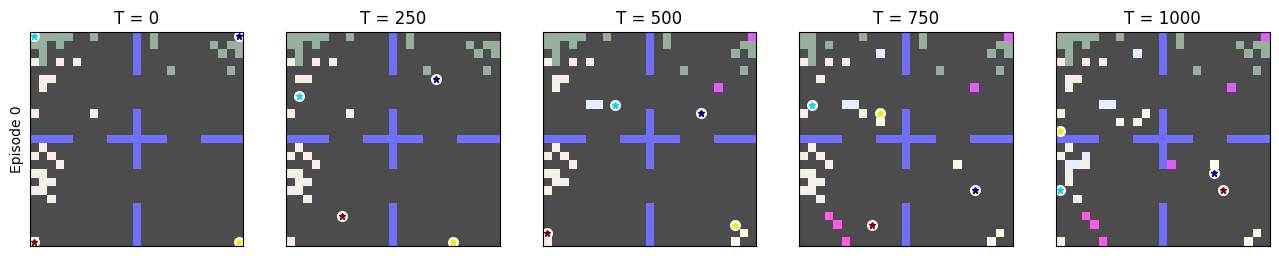

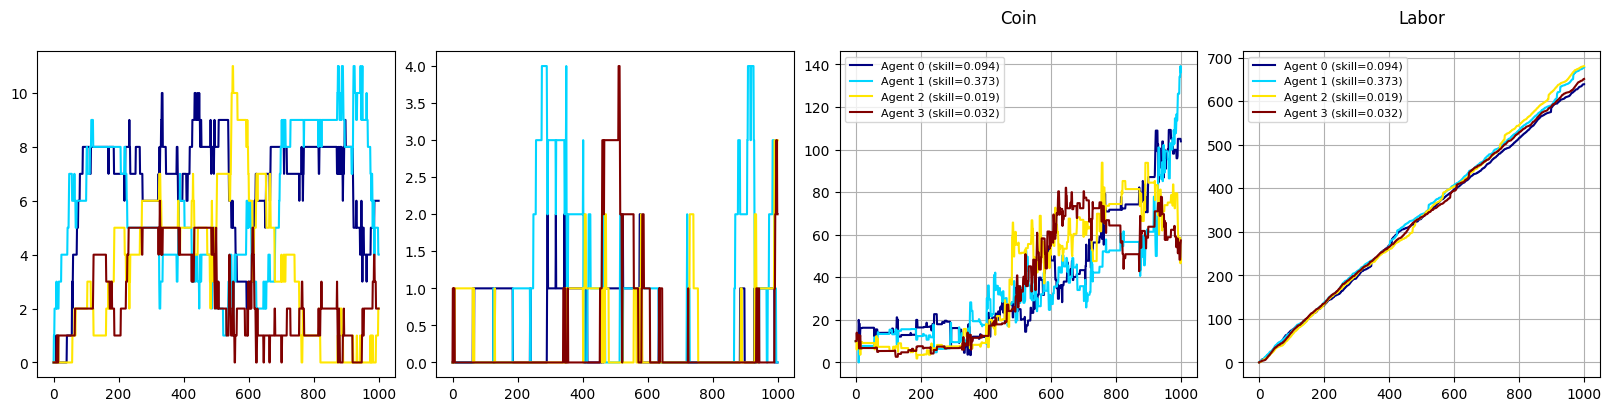

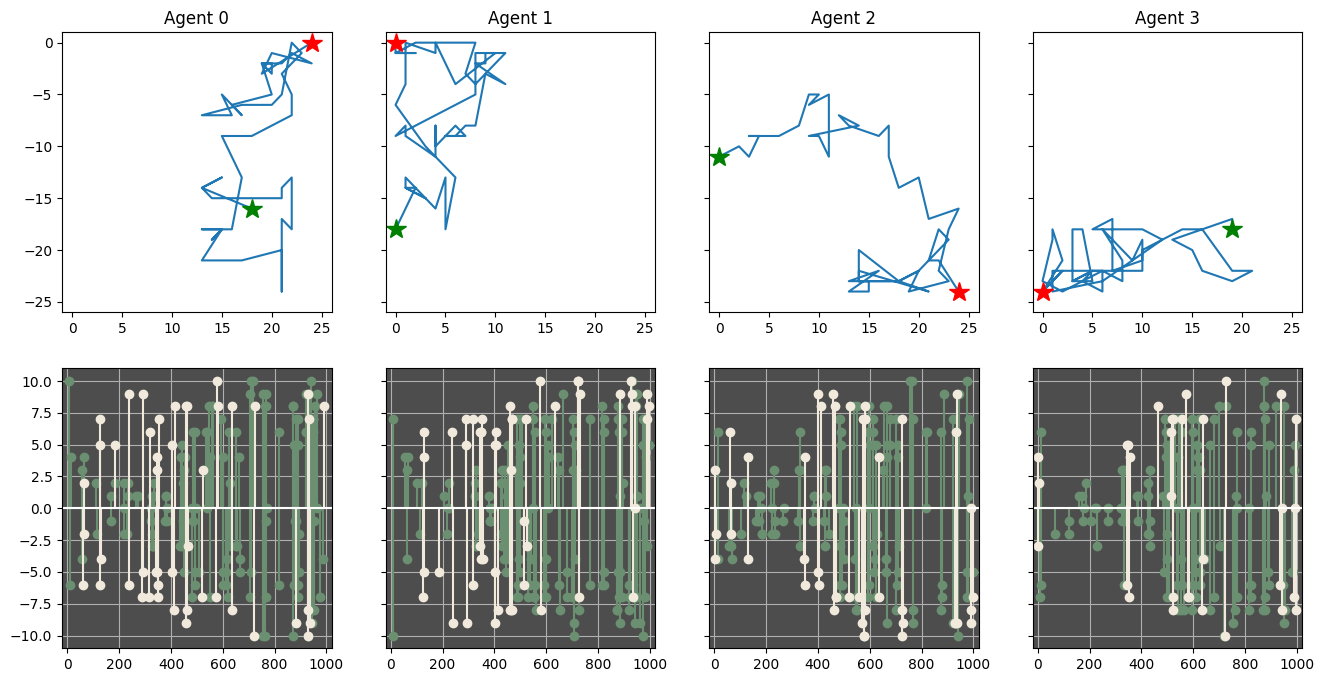

In [44]:
env_ = foundation.make_env_instance(**env_config_planner)
obs = env_p.reset()

obs = env_p.reset(force_dense_logging=True)

for t in range(env_p.episode_length):
    actions = sample_random_actions(env_p, obs)
    obs, rew, done, info = env_p.step(actions)

dense_log = env_p.previous_episode_dense_log

plotting.breakdown(dense_log)

In [45]:
def log_planner_actions(env, log_every=100):
    """
    Run an episode and log planner actions & chosen tax rates every `log_every` steps.
    Returns a list of dict logs.
    """
    planner = env.world.planner
    tax_comp = env.get_component("PeriodicBracketTax")

    obs = env.reset()
    done = {"__all__": False}

    logs = []

    t = 0
    while not done["__all__"]:
        # === Sample actions for all agents (using your working sampler) ===
        actions = sample_random_actions(env, obs)

        # === Step ===
        obs, rew, done, info = env.step(actions)
        t += 1

        # === Log every X timesteps ===
        if t % log_every == 0:
            entry = {
                "timestep": t,
                "tax_cycle_pos": tax_comp.tax_cycle_pos,
                "is_tax_day": (tax_comp.tax_cycle_pos == 1),
                "planner_raw_action": actions[planner.idx],
                "bracket_names": list(planner.action_dim.keys()),
                "selected_indices": list(actions[planner.idx]),
                "selected_rates": [
                    tax_comp.discrete_rates[idx-1] if idx > 0 else 0.0
                    for idx in actions[planner.idx]
                ],
            }
            logs.append(entry)

    return logs

def pretty_print_planner_action(entry):
    print(f"\n=== Timestep {entry['timestep']} ===")
    print(f"Tax-day? {entry['is_tax_day']}  (cycle pos: {entry['tax_cycle_pos']})")
    print("Bracket | Index | Rate")
    for name, idx, rate in zip(entry["bracket_names"],
                               entry["selected_indices"],
                               entry["selected_rates"]):
        print(f"{name:45s}  {idx:4d}    {rate:6.3f}")

In [46]:
env_p = foundation.make_env_instance(**env_config_planner)
logs = log_planner_actions(env_p, log_every=10)

for entry in logs:
    print("\n---- Timestep", entry["timestep"], "----")
    print("Tax cycle pos:", entry["tax_cycle_pos"], 
          " | is_tax_day:", entry["is_tax_day"])
    print("Selected bracket indices:", entry["selected_indices"])
    print("Selected marginal rates:", entry["selected_rates"])


---- Timestep 10 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 20 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 30 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 40 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 50 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 60 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0

In [47]:
for entry in logs:
    pretty_print_planner_action(entry)


=== Timestep 10 ===
Tax-day? True  (cycle pos: 1)
Bracket | Index | Rate
PeriodicBracketTax.TaxIndexBracket_000            0     0.000
PeriodicBracketTax.TaxIndexBracket_009            0     0.000
PeriodicBracketTax.TaxIndexBracket_039            0     0.000
PeriodicBracketTax.TaxIndexBracket_084            0     0.000
PeriodicBracketTax.TaxIndexBracket_160            0     0.000
PeriodicBracketTax.TaxIndexBracket_204            0     0.000
PeriodicBracketTax.TaxIndexBracket_510            0     0.000

=== Timestep 20 ===
Tax-day? True  (cycle pos: 1)
Bracket | Index | Rate
PeriodicBracketTax.TaxIndexBracket_000            0     0.000
PeriodicBracketTax.TaxIndexBracket_009            0     0.000
PeriodicBracketTax.TaxIndexBracket_039            0     0.000
PeriodicBracketTax.TaxIndexBracket_084            0     0.000
PeriodicBracketTax.TaxIndexBracket_160            0     0.000
PeriodicBracketTax.TaxIndexBracket_204            0     0.000
PeriodicBracketTax.TaxIndexBracket_510        

In [48]:
env_p.world.planner

# We try something new

In [49]:
# Define a configuration (dictionary) for the "gather-trade-build" environment.

env_config_dict = {
    # ===== SCENARIO CLASS =====
    # Which Scenario class to use: the class's name in the Scenario Registry (foundation.scenarios).
    # The environment object will be an instance of the Scenario class.
    'scenario_name': 'layout_from_file/simple_wood_and_stone',
    
    # ===== COMPONENTS =====
    # Which components to use (specified as list of ("component_name", {component_kwargs}) tuples).
    #   "component_name" refers to the Component class's name in the Component Registry (foundation.components)
    #   {component_kwargs} is a dictionary of kwargs passed to the Component class
    # The order in which components reset, step, and generate obs follows their listed order below.
    'components': [
        # (1) Building houses
        ('Build', {
            'skill_dist':                   'pareto', 
            'payment_max_skill_multiplier': 3,
            'build_labor':                  10,
            'payment':                      10
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {
            'max_bid_ask':    10,
            'order_labor':    0.25,
            'max_num_orders': 5,
            'order_duration': 50
        }),
        # (3) Movement and resource collection
        ('Gather', {
            'move_labor':    1,
            'collect_labor': 1,
            'skill_dist':    'pareto'
        }),
        # (4) Planner
        ('PeriodicBracketTax', {
            'period':          100,
            'bracket_spacing': 'us-federal',
            'usd_scaling':     1000,
            'disable_taxes':   False
        })
    ],
    
    # ===== SCENARIO CLASS ARGUMENTS =====
    # (optional) kwargs that are added by the Scenario class (i.e. not defined in BaseEnvironment)
    'env_layout_file': 'quadrant_25x25_20each_30clump.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': True,
    
    # ===== STANDARD ARGUMENTS ======
    # kwargs that are used by every Scenario class (i.e. defined in BaseEnvironment)
    'n_agents': 4,          # Number of non-planner agents (must be > 1)
    'world_size': [25, 25], # [Height, Width] of the env world
    'episode_length': 1000, # Number of timesteps per episode
    
    # In multi-action-mode, the policy selects an action for each action subspace (defined in component code).
    # Otherwise, the policy selects only 1 action.
    'multi_action_mode_agents': False,
    'multi_action_mode_planner': True,
    
    # When flattening observations, concatenate scalar & vector observations before output.
    # Otherwise, return observations with minimal processing.
    'flatten_observations': True,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': True,
    
    # How often to save the dense logs
    'dense_log_frequency': 1
}

In [50]:
env_d = foundation.make_env_instance(**env_config_dict)
obs = env_d.reset()

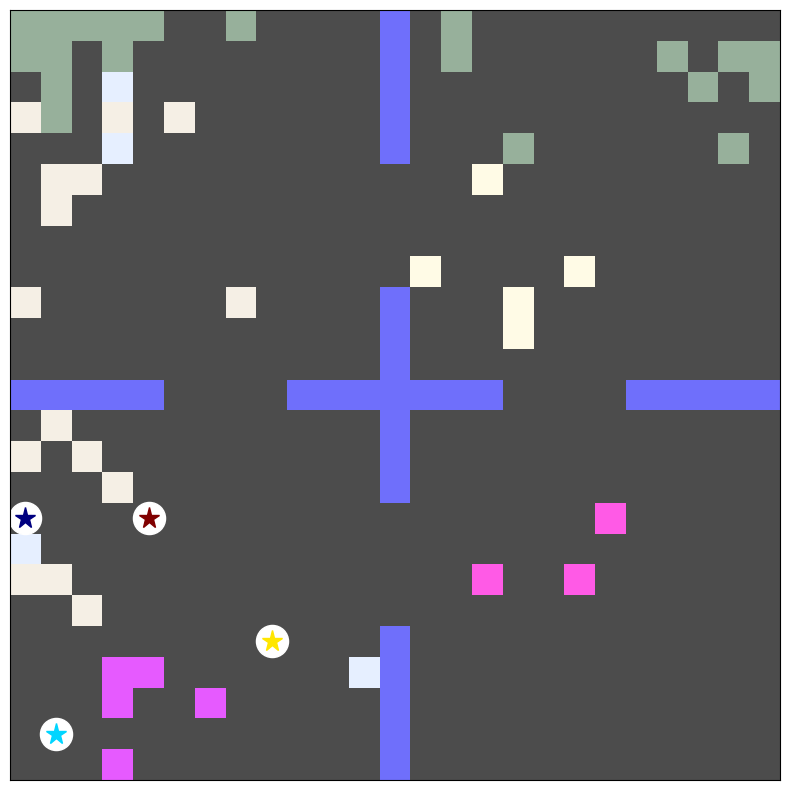

In [51]:
play_random_episode(env_d, plot_every=100)

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   4.81 (n= 86) |   4.54 (n= 61) |   4.57 (n= 70) |   4.33 (n= 66)
Cost (Stone)   :   6.81 (n= 42) |   6.22 (n= 18) |   6.46 (n= 35) |   6.61 (n= 36)

Income (Wood)  :   3.90 (n= 93) |   5.48 (n= 58) |   5.00 (n= 65) |   4.34 (n= 67)
Income (Stone) :   6.55 (n= 47) |   5.77 (n= 22) |   6.93 (n= 29) |   6.85 (n= 33)
Income (Build) :  16.47 (n= 16) |  13.27 (n=  2) |  22.25 (n=  5) |  11.33 (n=  3)


((<Figure size 1600x300 with 5 Axes>,
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1600x800 with 8 Axes>),
 {'Sell Stone': [308, 127, 201, 226],
  'Buy Stone': [-286, -112, -226, -238],
  'Sell Wood': [363, 318, 325, 291],
  'Buy Wood': [-414, -277, -320, -286],
  'Build': [263.5579671520981,
   26.53422467795859,
   111.24807152197867,
   33.99492187077029],
  'Total': array([234.55796715,  82.53422468,  91.24807152,  26.99492187])},
 [244, 92, 101, 36],
 {'Stone': [{'t': 1,
    't_ask': 1,
    't_bid': 0,
    'commodity': 'Stone',
    'buyer': 2,
    'bid': 4,
    'bid_lifetime': 1,
    'seller': 1,
    'ask': 0,
    'ask_lifetime': 0,
    'price': 4,
    'cost': 4,
    'income': 4},
   {'t': 3,
    't_ask': 3,
    't_bid': 0,
    'commodity': 'Stone',
    'buyer': 1,
    'bid': 8,
    'bid_lifetime': 3,
    'seller': 2,
    'ask': 8,
    'ask_lifetime': 0,
    'price': 8,
    'cost': 8,
    'income': 8},
   {'t': 7,
    't_ask': 7,
    't_bid': 6,
    'commodity': 'Stone',
 

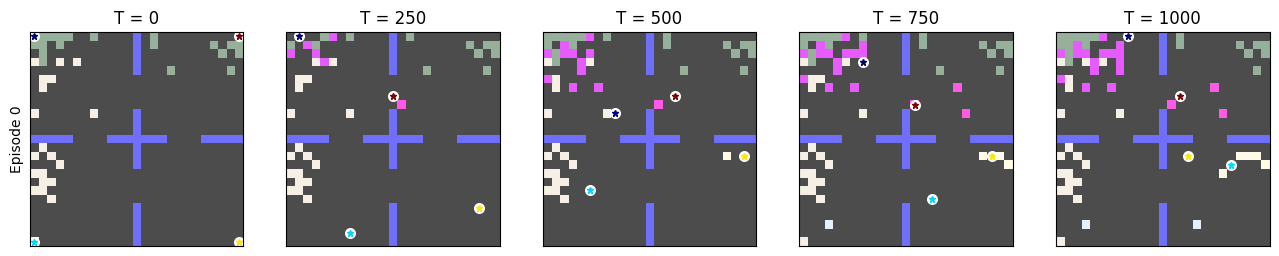

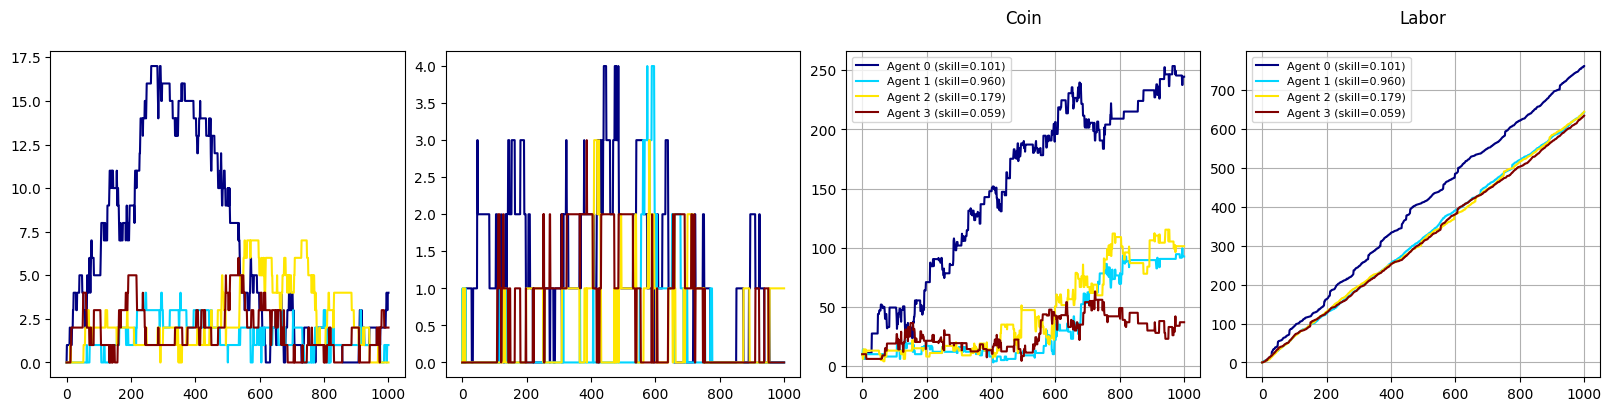

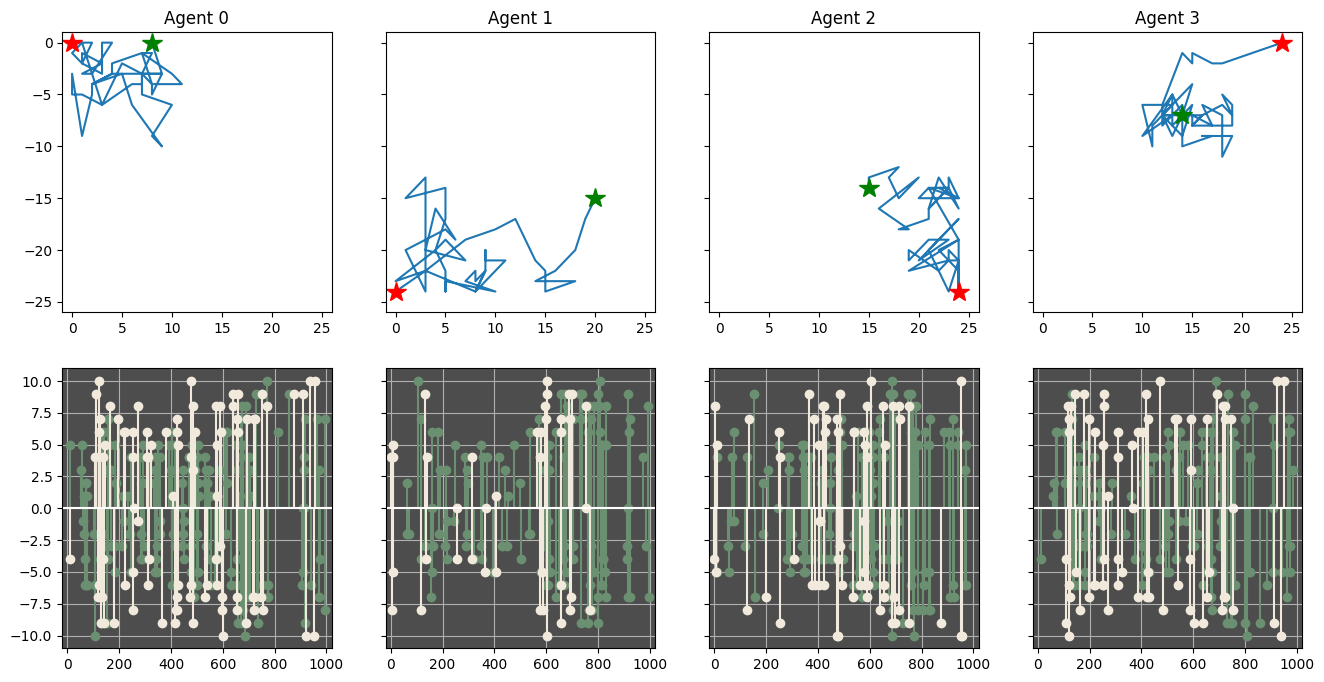

In [52]:
obs = env_d.reset(force_dense_logging=True)

for t in range(env_d.episode_length):
    actions = sample_random_actions(env_d, obs)
    obs, rew, done, info = env_d.step(actions)

dense_log = env_d.previous_episode_dense_log

plotting.breakdown(dense_log)

In [53]:

logs = log_planner_actions(env_d, log_every=100)

for entry in logs:
    print("\n---- Timestep", entry["timestep"], "----")
    print("Tax cycle pos:", entry["tax_cycle_pos"], 
          " | is_tax_day:", entry["is_tax_day"])
    print("Selected bracket indices:", entry["selected_indices"])
    print("Selected marginal rates:", entry["selected_rates"])


---- Timestep 100 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 200 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 300 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 400 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 500 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

---- Timestep 600 ----
Tax cycle pos: 1  | is_tax_day: True
Selected bracket indices: [0, 0, 0, 0, 0, 0, 0]
Selected marginal rates: [0.0, 0.0, 0.0, 

In [54]:
print("t =", env_d.world.timestep,
      "tax_cycle_pos =", env_d.get_component("PeriodicBracketTax").tax_cycle_pos, 
      "planner_action =", actions[p_id])

t = 1000 tax_cycle_pos = 1 planner_action = [0, 0, 0, 0, 0, 0, 0]


In [55]:
from ai_economist import foundation
import numpy as np

# 1) Build env with your config
env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()
tax_comp = env.get_component("PeriodicBracketTax")
planner = env.world.planner

print("Planner action_dim:", planner.action_dim)   # Expect 7 keys (one per bracket)
print("n_disc_rates:", tax_comp.n_disc_rates)      # e.g., 21 or 22 depending on rate_disc/range

# Helper to build a valid multi-action list for the planner
def midrate_action():
    # planner.action_dim values include NO-OP in multi-action mode -> they are N+1
    # But tax masks for model_wrapper typically expose N entries (no NO-OP) in the mask.
    # The action indices the planner sends are: 0=NO-OP, 1..N=valid tax.
    N_list = []
    for k, n_with_noop in planner.action_dim.items():
        N_list.append(n_with_noop - 1)
    # pick the middle rate: e.g., idx= N//2  (remember planner needs +1 to avoid 0)
    return [ (N//2) if (N//2) > 0 else 1 for N in N_list ]

# 2) Run for a few hundred steps:
for t in range(1, 301):
    actions = {}

    # Workers: NO-OP just for isolation (won't block planner taxes)
    for a in env.world.agents:
        actions[str(a.idx)] = 0

    # --- PLANNER ACTIONS ---
    # Read the planner mask from *obs*, because this is what the policy would see.
    p_mask = obs.get(planner.idx, {}).get("action_mask", None)

    # Only on tax day (start of period), the component allows non-zero choices.
    if tax_comp.tax_cycle_pos == 1:
        # Force a NON-zero schedule regardless of mask shape.
        # We send a valid multi-action LIST of length = number of brackets.
        actions[planner.idx] = midrate_action()
        forced = True
    else:
        # Not tax day: must send NO-OPs for each subspace
        actions[planner.idx] = [0] * len(planner.action_dim)
        forced = False

    obs, rew, done, info = env.step(actions)

    # Log at the same step we act (to avoid off-by-1)
    if t % 10 == 0 or forced:
        print(f"t={t:3d}  tax_cycle_pos={tax_comp.tax_cycle_pos}  forced={forced}  planner_action={actions[planner.idx]}")

    if done["__all__"]:
        break

# After: check tax metrics
print("\nTAX METRICS:", env.get_component("PeriodicBracketTax").get_metrics())

Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
n_disc_rates: 21
t=  1  tax_cycle_pos=2  forced=True  planner_action=[10, 10, 10, 10, 10, 10, 10]
t= 10  tax_cycle_pos=11  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 20  tax_cycle_pos=21  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 30  tax_cycle_pos=31  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 40  tax_cycle_pos=41  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 50  tax_cycle_pos=51  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 60  tax_cycle_pos=61  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 70  tax_cycle_pos=71  forced=False  planner_action=[0, 0, 0, 0, 0, 0, 0]
t= 80  tax_cycle_pos=81  fo

In [56]:
print("Planner subspace names:", list(planner.action_dim.keys()))
print("Tax component bracket cutoffs:", tax_comp.bracket_cutoffs)

Planner subspace names: ['PeriodicBracketTax.TaxIndexBracket_000', 'PeriodicBracketTax.TaxIndexBracket_009', 'PeriodicBracketTax.TaxIndexBracket_039', 'PeriodicBracketTax.TaxIndexBracket_084', 'PeriodicBracketTax.TaxIndexBracket_160', 'PeriodicBracketTax.TaxIndexBracket_204', 'PeriodicBracketTax.TaxIndexBracket_510']
Tax component bracket cutoffs: [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]


In [57]:
def log_planner_actions(env, log_every=10, policy="mid"):
    """
    Runs one episode, logs planner actions & rates every `log_every`.
    Works with flatten_masks=True (flat 1-D planner mask), multi-action planner.
    policy: "mid" (choose middle), "random" (sample from masks), "zero" (no-op).
    """
    tax_comp = env.get_component("PeriodicBracketTax")
    planner = env.world.planner

    # Precompute per-subspace lengths (with NO-OP)
    subspaces = list(planner.action_dim.items())  # [(name, n_with_noop), ...]
    n_with_noop = [n for _, n in subspaces]
    # model_wrapper mask length per subspace (no NO-OP inside mask)
    n_noopless = [n-1 for n in n_with_noop]
    # cumulative offsets for flat mask slicing
    offsets = np.cumsum([0] + n_noopless[:-1])

    def split_flat_mask(flat):
        """Split the flat planner mask (no NO-OP entries) into list of per-subspace arrays."""
        flat = np.asarray(flat).ravel()
        parts = []
        for n, off in zip(n_noopless, offsets):
            parts.append(flat[off:off+n])
        return parts

    obs = env.reset()
    logs = []
    done = {"__all__": False}
    t = 0

    while not done["__all__"]:
        t += 1
        actions = {}

        # Workers: do something minimal (NO-OP is fine for logging planner)
        for a in env.world.agents:
            actions[str(a.idx)] = 0

        # Planner decision
        p_obs = obs.get(planner.idx, {})
        p_mask_flat = p_obs.get("action_mask", None)  # May be flat 1-D array or None

        if tax_comp.tax_cycle_pos == 1:
            # Tax day: we can set taxes
            if policy == "mid":
                chosen = [ max(1, (n//2)) for n in n_noopless ]   # choose mid rate per bracket (index 1..N)
            elif policy == "zero":
                chosen = [0]*len(n_noopless)
            else: # random, respecting mask
                chosen = []
                if p_mask_flat is None:
                    # No mask provided – pick uniformly from 1..N, avoid 0
                    for n in n_noopless:
                        chosen.append(np.random.randint(1, n+1))
                else:
                    parts = split_flat_mask(p_mask_flat)
                    for part in parts:
                        if part.sum() <= 0:
                            chosen.append(0)  # fallback no-op
                        else:
                            probs = part / part.sum()
                            # +1 to shift [0..N-1] -> [1..N] (since 0 is NO-OP)
                            chosen.append(int(np.random.choice(len(part), p=probs)) + 1)
            actions[planner.idx] = chosen
        else:
            # Not tax day: must no-op
            actions[planner.idx] = [0]*len(n_noopless)

        obs, rew, done, info = env.step(actions)

        if t % log_every == 0 or tax_comp.tax_cycle_pos == 1:
            # Compute marginal rates from chosen indices
            chosen = actions[planner.idx]
            rates = [ (tax_comp.disc_rates[idx-1] if idx>0 else 0.0) for idx in chosen ]
            logs.append({
                "t": t,
                "tax_cycle_pos": tax_comp.tax_cycle_pos,
                "chosen": chosen,
                "rates": rates
            })
            print(f"t={t:4d}  pos={tax_comp.tax_cycle_pos:3d}  chosen={chosen}  rates={np.round(rates,3)}")

    return logs

In [58]:
env = foundation.make_env_instance(**env_config_dict)
logs = log_planner_actions(env, log_every=10, policy="mid")

print("\nFinal tax metrics:", env.get_component("PeriodicBracketTax").get_metrics())

t=  10  pos= 11  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  20  pos= 21  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  30  pos= 31  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  40  pos= 41  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  50  pos= 51  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  60  pos= 61  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  70  pos= 71  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  80  pos= 81  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t=  90  pos= 91  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t= 100  pos=  1  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t= 110  pos= 11  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t= 120  pos= 21  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t= 130  pos= 31  chosen=[0, 0, 0, 0, 0, 0, 0]  rates=[0. 0. 0. 0. 0. 0. 0.]
t= 140  pos=

In [59]:
p = env.world.planner
pm = obs[p.idx].get("action_mask", None)
print("Mask present?", pm is not None, "  shape:", None if pm is None else np.asarray(pm).shape)
print("Mask sum:", None if pm is None else float(np.asarray(pm).sum()))
print("action_dim:", p.action_dim)
print("n_disc_rates:", env.get_component("PeriodicBracketTax").n_disc_rates)

Mask present? True   shape: (154,)
Mask sum: 154.0
action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
n_disc_rates: 21


In [60]:
from ai_economist import foundation
import numpy as np

env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()

tax = env.get_component("PeriodicBracketTax")
planner = env.world.planner

print("\n\n=== BASIC CHECKS ===")
print("Planner idx:", planner.idx)
print("Planner action_dim:", planner.action_dim)
print("Number of subspaces:", len(planner.action_dim))
print("n_disc_rates:", tax.n_disc_rates)
print("bracket cutoffs:", tax.bracket_cutoffs)
print("tax_cycle_pos at reset:", tax.tax_cycle_pos)

print("\n=== RAW MASK FROM OBS ===")
print("Keys in obs[p]:", obs['p'].keys())
print("obs['p']['action_mask']:", obs['p'].get("action_mask"))
print("sum(mask):", None if obs['p'].get("action_mask") is None else np.sum(obs['p']['action_mask']))

print("\n=== RAW MASK FROM COMPONENT ===")
comp_masks = tax.generate_masks()
print("comp_masks keys:", comp_masks.keys())

# If planner exists in comp_masks, print it
print("comp_masks planner entry:", comp_masks.get(planner.idx, None))

#print("\n=== RAW ENV._all_masks JUST AFTER RESET ===")
#print(env._all_masks.get(planner.idx, None))



=== BASIC CHECKS ===
Planner idx: p
Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
Number of subspaces: 7
n_disc_rates: 21
bracket cutoffs: [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
tax_cycle_pos at reset: 1

=== RAW MASK FROM OBS ===
Keys in obs[p]: dict_keys(['world-map', 'world-idx_map', 'time', 'flat', 'p0', 'p1', 'p2', 'p3', 'action_mask'])
obs['p']['action_mask']: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.

In [61]:
env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()

# Force some taxes:
forced = [10,11,12,13,14,15,16]   # all non-zero rates
actions = { 'p': forced }

# Workers do nothing
for a in env.world.agents:
    actions[str(a.idx)] = 0

obs2, rew, done, info = env.step(actions)

tax = env.get_component("PeriodicBracketTax")

print("Curr bracket tax indices:", tax.curr_rate_indices)
print("Curr marginal rates:", tax.curr_marginal_rates)

Curr bracket tax indices: [9, 10, 11, 12, 13, 14, 15]
Curr marginal rates: [0.45 0.5  0.55 0.6  0.65 0.7  0.75]


In [62]:
from ai_economist import foundation
import numpy as np

env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()

planner = env.world.planner
tax = env.get_component("PeriodicBracketTax")

print("\n=== START OF TRACE ===")
print("Planner idx:", planner.idx)
print("Planner action_dim:", planner.action_dim)
print("n_disc_rates:", tax.n_disc_rates)
print("tax_cycle_pos:", tax.tax_cycle_pos)
print()

# ==== 1. Your sampler's output (we fake it here) ====
sampled = [5, 7, 10, 12, 14, 15, 20]   # random legal non-zero actions
print("1) Sampler output:", sampled)

# ==== 2. Let RLlibEnvWrapper process the actions ====
try:
    # build minimal action dict like RLlib would
    wrapper_actions = {planner.idx: np.array(sampled)}

    # RLlib wrapper applies action processing in step()
    # so we need to simulate one step call
    # we do a trick: call env.step and intercept what goes into Foundation
    # But Foundation env is env_obj.env inside wrapper, so we skip wrapper

    print("2) Giving to env.step() raw:", wrapper_actions)

    # ==== 3. Call step and capture what FOUNDATION receives ====
    # Workers no-op
    for ag in env.world.agents:
        wrapper_actions[str(ag.idx)] = 0

    obs2, rew, done, info = env.step(wrapper_actions)

    print("3) After env.step(), tax.curr_rate_indices:", tax.curr_rate_indices)
    print("   tax.curr_marginal_rates:", tax.curr_marginal_rates)

except Exception as e:
    print("ERROR:", e)

print("\n=== TRACE END ===\n")


=== START OF TRACE ===
Planner idx: p
Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
n_disc_rates: 21
tax_cycle_pos: 1

1) Sampler output: [5, 7, 10, 12, 14, 15, 20]
2) Giving to env.step() raw: {'p': array([ 5,  7, 10, 12, 14, 15, 20])}
3) After env.step(), tax.curr_rate_indices: [4, 6, 9, 11, 13, 14, 19]
   tax.curr_marginal_rates: [0.2  0.3  0.45 0.55 0.65 0.7  0.95]

=== TRACE END ===



In [63]:
from ai_economist import foundation
import numpy as np

FORCE_NON_ZERO_ON_TAX_DAY = False   # set True to prove env path without any policy or wrapper issues
PRINT_EVERY = 100

env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()
tax = env.get_component("PeriodicBracketTax")
planner = env.world.planner

# --- subspace sizes ---
subspaces = list(planner.action_dim.items())          # [(name, n_with_noop=22), ...]
n_noopless = [n-1 for _, n in subspaces]              # 21 each for model_wrapper
n_brackets = len(subspaces)

# For split of the flat planner mask (length = sum(n_noopless) = 7*21 = 147 or 154 if your build differs)
offsets = np.cumsum([0] + n_noopless[:-1])

def split_flat_mask(flat):
    flat = np.asarray(flat).ravel()
    parts = []
    for n, off in zip(n_noopless, offsets):
        parts.append(flat[off:off+n])
    return parts

def midrate_action():
    return [max(1, n//2) for n in n_noopless]   # choose middle (1..N); 0 is NO-OP

def random_masked_action(flat_mask):
    parts = split_flat_mask(flat_mask)
    chosen = []
    for part in parts:
        if part.sum() <= 0:
            chosen.append(0)                     # no-ops if masked out
        else:
            probs = part / part.sum()
            chosen.append(int(np.random.choice(len(part), p=probs)) + 1)  # +1 because 0=NO-OP
    return chosen

print("\n=== HARNESS START ===")
print("Planner idx:", planner.idx)
print("Planner action_dim:", planner.action_dim)
print("n_disc_rates:", tax.n_disc_rates)
print("Bracket cutoffs:", tax.bracket_cutoffs)
print("episode_length:", env.episode_length)
print("period:", tax.period)
#print("flatten_masks:", env.flatten_masks, "flatten_observations:", env.flatten_observations)
print("tax_cycle_pos at reset:", tax.tax_cycle_pos)

for t in range(1, env.episode_length + 1):
    actions = {}

    # Workers: do nothing (we only test planner path here)
    for a in env.world.agents:
        actions[str(a.idx)] = 0

    # --- Planner decision using *current obs* ---
    p_obs = obs.get(planner.idx, {})
    p_mask_flat = p_obs.get("action_mask", None)

    # Logs BEFORE step
    if (t % PRINT_EVERY == 0) or (tax.tax_cycle_pos == 1):
        print(f"\n[t={t:4d}] BEFORE STEP | tax_cycle_pos={tax.tax_cycle_pos}")
        if p_mask_flat is None:
            print("  planner mask: None")
        else:
            print("  planner mask sum:", float(np.asarray(p_mask_flat).sum()))
            # print just the first block for brevity; uncomment to see all
            parts = split_flat_mask(p_mask_flat)
            print("  first subspace mask (len):", len(parts[0]), " sum:", float(parts[0].sum()))

    # Build planner action
    if tax.tax_cycle_pos == 1:
        if FORCE_NON_ZERO_ON_TAX_DAY:
            chosen = midrate_action()
        else:
            # sample respecting mask
            chosen = random_masked_action(p_mask_flat) if p_mask_flat is not None else [0]*n_brackets
    else:
        chosen = [0]*n_brackets

    actions[planner.idx] = chosen

    if (t % PRINT_EVERY == 0) or (tax.tax_cycle_pos == 1):
        print("  planner chosen:", actions[planner.idx])

    # --- Step the env ---
    obs, rew, done, info = env.step(actions)

    # Logs AFTER step
    if (t % PRINT_EVERY == 0) or (tax.tax_cycle_pos == 2):  # 2 means we *just* set rates in step()
        print(f"  AFTER STEP      | tax_cycle_pos={tax.tax_cycle_pos}")
        print("  curr_rate_indices:", tax.curr_rate_indices)
        print("  curr_marginal_rates:", np.round(tax.curr_marginal_rates, 3))

    if done["__all__"]:
        break

print("\n=== HARNESS END ===")


=== HARNESS START ===
Planner idx: p
Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
n_disc_rates: 21
Bracket cutoffs: [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
episode_length: 1000
period: 100
tax_cycle_pos at reset: 1

[t=   1] BEFORE STEP | tax_cycle_pos=1
  planner mask sum: 154.0
  first subspace mask (len): 21  sum: 21.0
  planner chosen: [1, 17, 6, 8, 11, 8, 12]
  AFTER STEP      | tax_cycle_pos=2
  curr_rate_indices: [0, 16, 5, 7, 10, 7, 11]
  curr_marginal_rates: [0.   0.8  0.25 0.35 0.5  0.35 0.55]

[t= 100] BEFORE STEP | tax_cycle_pos=100
  planner mask sum: 7.0
  first subspace mask (len): 21  sum: 1.0
  planner chosen: [0, 0, 0, 0, 0, 0, 0]
  AFTER STEP      | tax_cy

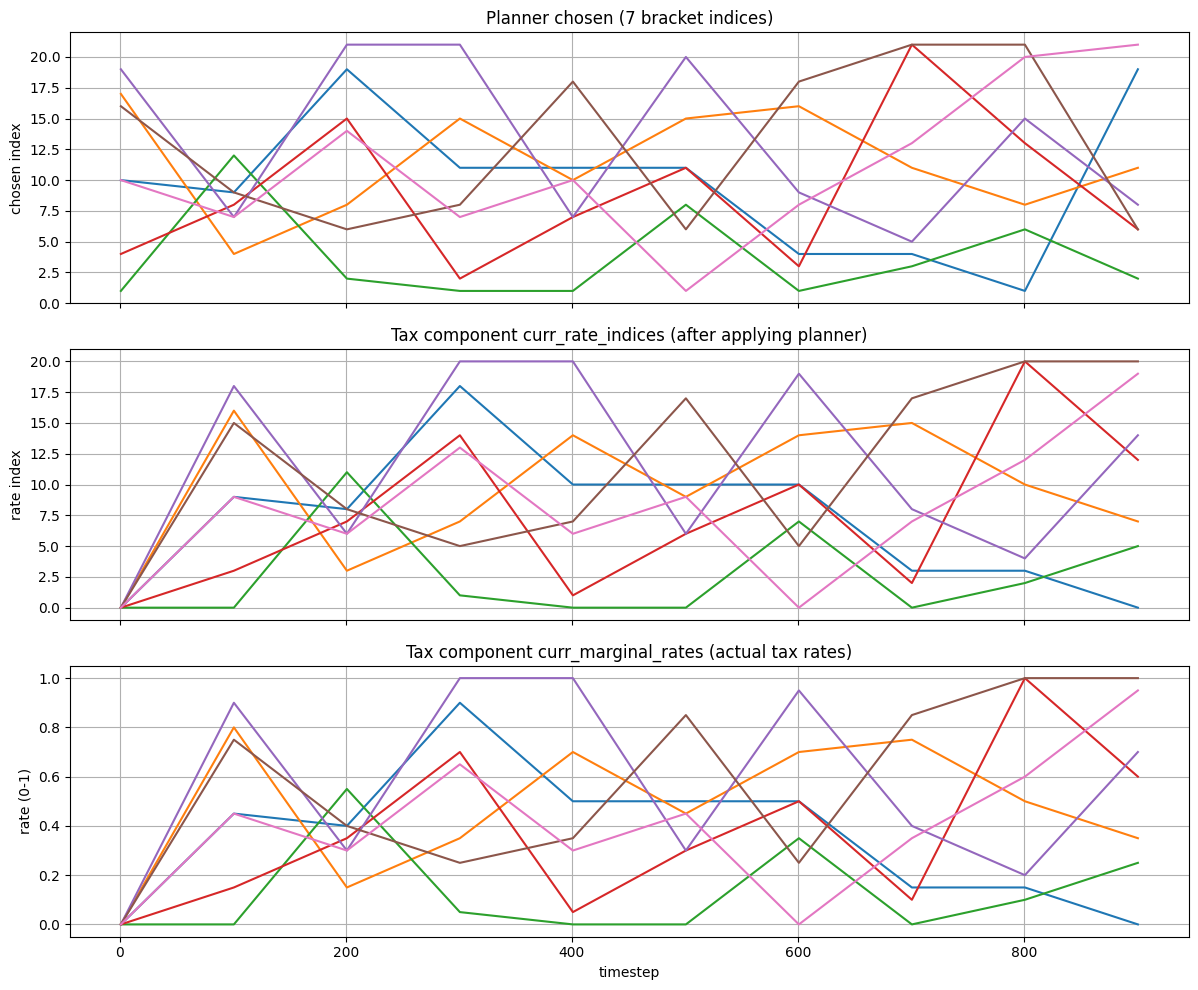

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# STORAGE FOR PLOTTING
# --------------------------
t_points = []
planner_chosen_log = []
rate_indices_log = []
marginal_rates_log = []

# Reset env again for clean logging run
env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()
tax = env.get_component("PeriodicBracketTax")
planner = env.world.planner

for t in range(1, env.episode_length + 1):
    actions = {}

    # Workers no-op
    for a in env.world.agents:
        actions[str(a.idx)] = 0

    # --- Planner ---
    p_obs = obs.get(planner.idx, {})
    p_mask_flat = p_obs.get("action_mask", None)

    # Compute mask sum safely
    mask_sum = float(np.asarray(p_mask_flat).sum()) if p_mask_flat is not None else 0.0

    # Detect tax day (full mask available)
    is_tax_day = mask_sum == 154

    # Build planner action
    if is_tax_day:
        chosen = random_masked_action(p_mask_flat)
    else:
        chosen = [0] * n_brackets
    actions[planner.idx] = chosen

    # Log only if mask sum == 154 (tax days t=1,101,201,...)
    if is_tax_day:
        t_points.append(t)
        planner_chosen_log.append(chosen.copy())
        rate_indices_log.append(list(tax.curr_rate_indices))
        marginal_rates_log.append(list(tax.curr_marginal_rates))

    # Step
    obs, rew, done, info = env.step(actions)

    if done["__all__"]:
        break

# --------------------------
# MAKE THE 3-PANEL FIGURE
# --------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Convert lists to arrays for easy plotting
planner_arr = np.array(planner_chosen_log)
rateidx_arr = np.array(rate_indices_log)
marg_arr = np.array(marginal_rates_log)

# Panel 1: planner chosen actions
axes[0].plot(t_points, planner_arr)
axes[0].set_title("Planner chosen (7 bracket indices)")
axes[0].set_ylabel("chosen index")
axes[0].grid(True)

# Panel 2: curr_rate_indices
axes[1].plot(t_points, rateidx_arr)
axes[1].set_title("Tax component curr_rate_indices (after applying planner)")
axes[1].set_ylabel("rate index")
axes[1].grid(True)

# Panel 3: curr_marginal_rates
axes[2].plot(t_points, marg_arr)
axes[2].set_title("Tax component curr_marginal_rates (actual tax rates)")
axes[2].set_xlabel("timestep")
axes[2].set_ylabel("rate (0-1)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

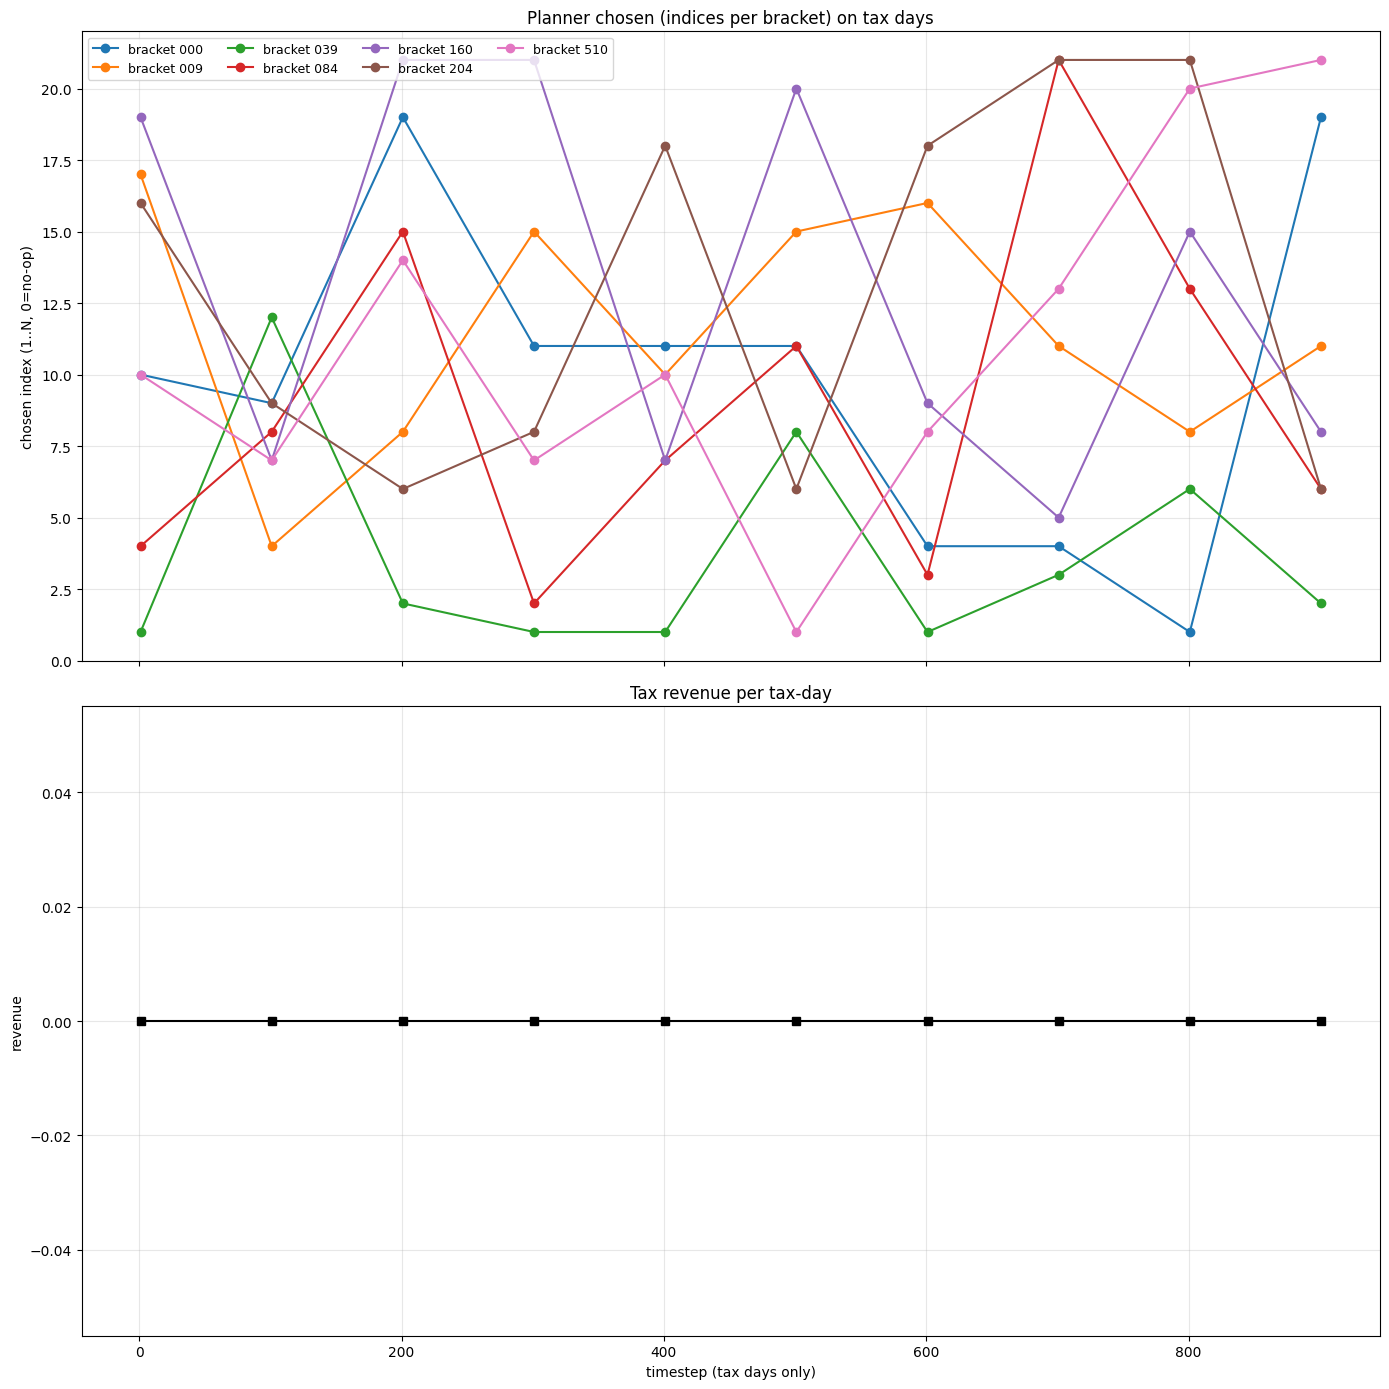

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# After your harness loop has filled:
#   t_points
#   planner_chosen_log
#   rate_indices_log
#   marginal_rates_log
# --------------------------
# We now additionally compute revenue per tax day.
tax = env.get_component("PeriodicBracketTax")

# A tax day entry exists only on the *last* timestep of the period.
# We take the revenue for the tax days corresponding to the t_points.
revenue_per_taxday = []
period = tax.period

for t_val in t_points:
    idx = t_val + (period - 1)
    if idx < len(tax.taxes):
        td = tax.taxes[idx]
        if td:   # empty if not actually a tax-collection point
            revenue_per_taxday.append(float(td.get("total_revenue", td["000"]["lump_sum"]*len(env.world.agents))))
        else:
            revenue_per_taxday.append(0.0)
    else:
        revenue_per_taxday.append(0.0)

# Convert logs to arrays
planner_arr = np.array(planner_chosen_log)      # (K, 7)
rateidx_arr = np.array(rate_indices_log)        # (K, 7)
marg_arr    = np.array(marginal_rates_log)      # (K, 7)

bracket_labels = [f"{int(c):03d}" for c in tax.bracket_cutoffs]
n_brackets = len(bracket_labels)


# --------------------------
# (A) 4-PANEL FIGURE (with legends)
# --------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

# Panel 1: Planner chosen
for b in range(n_brackets):
    axes[0].plot(t_points, planner_arr[:, b], marker='o', label=f"bracket {bracket_labels[b]}")
axes[0].set_title("Planner chosen (indices per bracket) on tax days")
axes[0].set_ylabel("chosen index (1..N, 0=no-op)")
axes[0].legend(loc="upper left", ncol=4, fontsize=9)
axes[0].grid(True, alpha=0.3)

# # Panel 2: curr_rate_indices
# for b in range(n_brackets):
#     axes[1].plot(t_points, rateidx_arr[:, b], marker='o', label=f"bracket {bracket_labels[b]}")
# axes[1].set_title("Tax component: curr_rate_indices")
# axes[1].set_ylabel("rate index (0..N-1)")
# axes[1].grid(True, alpha=0.3)

# # Panel 3: curr_marginal_rates
# for b in range(n_brackets):
#     axes[2].plot(t_points, marg_arr[:, b], marker='o', label=f"bracket {bracket_labels[b]}")
# axes[2].set_title("Tax component: curr_marginal_rates")
# axes[2].set_ylabel("rate (0..1)")
# axes[2].grid(True, alpha=0.3)

# Panel 4: Revenue
axes[1].plot(t_points, revenue_per_taxday, marker='s', color='black')
axes[1].set_title("Tax revenue per tax-day")
axes[1].set_xlabel("timestep (tax days only)")
axes[1].set_ylabel("revenue")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
def log_planner_actions_taxday_only(env):
    tax = env.get_component("PeriodicBracketTax")
    planner = env.world.planner

    obs = env.reset()
    logs = []
    for t in range(1, env.episode_length + 1):
        # --- Build a safe action dict (workers no-op) ---
        actions = {str(a.idx): 0 for a in env.world.agents}

        # If it's tax-day, show what the planner could choose *and* what we send
        if tax.tax_cycle_pos == 1:
            p_obs = obs.get(planner.idx, {})
            p_mask_flat = p_obs.get("action_mask", None)

            # split the flat mask into 7 per-bracket parts
            subspaces = list(planner.action_dim.items())
            n_noopless = [n-1 for _, n in subspaces]
            offsets = [0]
            for n in n_noopless[:-1]:
                offsets.append(offsets[-1] + n)

            parts = []
            if p_mask_flat is not None:
                m = np.asarray(p_mask_flat).ravel()
                for n, off in zip(n_noopless, offsets):
                    parts.append(m[off:off+n])

            # choose mid-rate for visibility (index 1..N; 0=NO-OP)
            chosen = [max(1, n//2) for n in n_noopless]
            actions[planner.idx] = chosen

            print(f"\n[t={t}] TAX-DAY")
            print("  mask_sums_per_bracket:", [float(x.sum()) for x in parts] if parts else "None")
            print("  chosen (1..N):", chosen)

        else:
            actions[planner.idx] = [0] * len(planner.action_dim)

        obs, rew, done, info = env.step(actions)

        if tax.tax_cycle_pos == 2:   # immediately after setting taxes
            entry = {
                "t": t,
                "curr_rate_indices": list(tax.curr_rate_indices),
                "curr_marginal_rates": list(map(float, tax.curr_marginal_rates)),
            }
            logs.append(entry)
            print("  -> curr_rate_indices:", entry["curr_rate_indices"])
            print("  -> curr_marginal_rates:", np.round(entry["curr_marginal_rates"], 3))

        if done["__all__"]:
            break

    return logs

In [67]:
import numpy as np

def sample_worker_action_valid(agent, worker_obs_mask):
    """
    Workers are single-action agents in your setup.
    worker_obs_mask is a **dict of sub-masks** (e.g., {'Build': [..], 'CDA.Buy_Wood': [..], ...}).
    We use agent.flatten_masks(mask_dict) to get the correct 1-D vector (with global NO-OP at index 0).
    """
    if not isinstance(worker_obs_mask, dict):
        # fallback: no mask -> NO-OP
        return 0
    flat = agent.flatten_masks(worker_obs_mask)  # correct order + NO-OP handling
    flat = np.asarray(flat, dtype=float).ravel()
    s = flat.sum()
    if s <= 0 or not np.isfinite(s):
        # fallback uniform
        probs = np.ones_like(flat) / len(flat)
    else:
        probs = flat / s
    return int(np.random.choice(len(probs), p=probs))

In [68]:
from ai_economist import foundation

env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()
tax = env.get_component("PeriodicBracketTax")
planner = env.world.planner

for t in range(1, env.episode_length + 1):
    actions = {}

    # Workers: sample valid action from masks
    for a in env.world.agents:
        a_id = str(a.idx)
        w_mask = obs[a_id].get("action_mask", None)
        actions[a_id] = sample_worker_action_valid(a, w_mask)

    # Planner: only on tax-day; pick mid rates so we see changes
    if tax.tax_cycle_pos == 1:
        n_noopless = [n-1 for _, n in planner.action_dim.items()]
        actions[planner.idx] = [max(1, n//2) for n in n_noopless]
    else:
        actions[planner.idx] = [0] * len(planner.action_dim)

    obs, rew, done, info = env.step(actions)
    if done["__all__"]:
        break

print("\nTax metrics:", tax.get_metrics())


Tax metrics: {'avg_bracket_rate/000': np.float64(0.45), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.45), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.45), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.45), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.45), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.45), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.45), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [69]:
('PeriodicBracketTax', dict(period=10, bracket_spacing="us-federal", usd_scaling=1000, disable_taxes=False))

('PeriodicBracketTax',
 {'period': 10,
  'bracket_spacing': 'us-federal',
  'usd_scaling': 1000,
  'disable_taxes': False})

In [70]:
import numpy as np

def sample_worker_action_mask_biased(agent, obs_mask_dict, bias_gather=0.7, bias_build=0.2):
    """
    Single-action agent. Uses the agent's own flatten_masks for validity, but
    biases toward Gather/Build when those submasks allow it.
    """
    # Fallback: no mask -> NO-OP
    if not isinstance(obs_mask_dict, dict):
        return 0

    # Quick access to sub-masks (if missing, treat as all zeros)
    def sm(name, length=None):
        v = np.asarray(obs_mask_dict.get(name, []), dtype=float)
        return v if length is None else (v if len(v) == length else np.zeros(length))

    # Names as your env constructs them:
    # ['Build', 'ContinuousDoubleAuction.Buy_Stone', 'ContinuousDoubleAuction.Sell_Stone',
    #  'ContinuousDoubleAuction.Buy_Wood', 'ContinuousDoubleAuction.Sell_Wood', 'Gather']
    build_mask  = sm("Build", 1)                    # length 1
    gather_mask = sm("Gather", 4)                   # length 4

    # If Build is allowed (mask==1), give it some chance
    if build_mask.sum() > 0 and np.random.rand() < bias_build:
        # Build is a single sub-action; we need its flattened index
        flat = agent.flatten_masks(obs_mask_dict)
        # Find the position of Build=1 in the flat vector
        # flat = [NO-OP] + Build(1) + CDA... + Gather(4)
        # It's simplest to sample from the true flat probs with a boosted weight for Build.
        weights = flat.copy().astype(float)
        # Boost the build slot
        # NO-OP at index 0, Build at index 1
        if len(weights) > 1:
            weights[1] *= 5.0
        s = weights.sum()
        if s > 0:
            return int(np.random.choice(len(weights), p=weights/s))

    # Otherwise: bias Gather if any move is available
    if gather_mask.sum() > 0 and np.random.rand() < bias_gather:
        # Again, sample from the flat mask with a boost on gather slots
        flat = agent.flatten_masks(obs_mask_dict).astype(float)
        # Identify gather block indices: last 4 positions in the flat mask
        # flat layout: [NO-OP](1) + Build(1) + BuyS(11)+SellS(11)+BuyW(11)+SellW(11)+Gather(4) = length 50
        if len(flat) >= 1 + 1 + 11 + 11 + 11 + 11 + 4:
            g_start = len(flat) - 4
            g_end = len(flat)
            flat[g_start:g_end] *= 3.0  # boost gather
        s = flat.sum()
        if s > 0 and np.isfinite(s):
            return int(np.random.choice(len(flat), p=flat/s))

    # Otherwise: sample any valid action (including CDA chances)
    flat = agent.flatten_masks(obs_mask_dict).astype(float)
    s = flat.sum()
    if s <= 0 or not np.isfinite(s):
        return 0
    return int(np.random.choice(len(flat), p=flat/s))

In [71]:
from ai_economist import foundation

# Make period short for visibility
env_cfg_test = dict(env_config_dict)
components = []
for name, kwargs in env_cfg_test['components']:
    if name == 'PeriodicBracketTax':
        kwargs = dict(kwargs)
        kwargs['period'] = 10
    components.append((name, kwargs))
env_cfg_test['components'] = components

env = foundation.make_env_instance(**env_cfg_test)
obs = env.reset()
tax = env.get_component("PeriodicBracketTax")
planner = env.world.planner

# Planner: set mid rates on tax-day so we have a stable schedule
n_noopless = [n-1 for _, n in planner.action_dim.items()]
mid = [max(1, n//2) for n in n_noopless]

for t in range(1, 201):  # ~20 collection cycles with period=10
    actions = {}

    # Workers: biased sampler
    for a in env.world.agents:
        a_id = str(a.idx)
        w_mask = obs[a_id].get("action_mask", None)
        actions[a_id] = sample_worker_action_mask_biased(a, w_mask)

    # Planner: only on tax-day
    if tax.tax_cycle_pos == 1:
        actions[planner.idx] = mid
    else:
        actions[planner.idx] = [0]*len(planner.action_dim)

    obs, rew, done, info = env.step(actions)
    if done['__all__']:
        break

print("\nTax metrics (period=10 test):", tax.get_metrics())


Tax metrics (period=10 test): {'avg_bracket_rate/000': np.float64(0.4499999999999999), 'bracket_occupancy/000': np.float64(1.0), 'avg_bracket_rate/009': np.float64(0.4499999999999999), 'bracket_occupancy/009': np.float64(0.0), 'avg_bracket_rate/039': np.float64(0.4499999999999999), 'bracket_occupancy/039': np.float64(0.0), 'avg_bracket_rate/084': np.float64(0.4499999999999999), 'bracket_occupancy/084': np.float64(0.0), 'avg_bracket_rate/160': np.float64(0.4499999999999999), 'bracket_occupancy/160': np.float64(0.0), 'avg_bracket_rate/204': np.float64(0.4499999999999999), 'bracket_occupancy/204': np.float64(0.0), 'avg_bracket_rate/510': np.float64(0.4499999999999999), 'bracket_occupancy/510': np.float64(0.0), 'avg_effective_tax_rate': np.float64(0.0), 'total_collected_taxes': 0.0, 'avg_tax_rate/poorest': np.float64(0.0), 'avg_tax_rate/richest': np.float64(0.0)}


In [72]:
tax = env.get_component("PeriodicBracketTax")
tax_days = tax.taxes[(tax.period - 1)::tax.period]  # entries at period ends

for i, tax_day in enumerate(tax_days, 1):
    if not tax_day:
        continue  # empty entries on non-collection steps
    print(f"\nTax day {i}:")
    print("  schedule:", np.round(tax_day['schedule'], 3))
    print("  cutoffs :", np.round(tax_day['cutoffs'], 3))
    for a in env.world.agents:
        k = str(a.idx)
        rec = tax_day[k]
        print(f"  agent {k}: income={rec['income']:.3f}  tax_paid={rec['tax_paid']:.3f}  eff_rate={rec['effective_rate']:.3f}")
    print(f"  lump_sum per agent: {tax_day[str(env.world.agents[0].idx)]['lump_sum']:.3f}")


Tax day 1:
  schedule: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
  cutoffs : [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
  agent 0: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 1: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 2: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 3: income=0.000  tax_paid=0.000  eff_rate=0.000
  lump_sum per agent: 0.000

Tax day 2:
  schedule: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
  cutoffs : [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
  agent 0: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 1: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 2: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 3: income=0.000  tax_paid=0.000  eff_rate=0.000
  lump_sum per agent: 0.000

Tax day 3:
  schedule: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
  cutoffs : [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
  agent 0: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 1: income=0.000  tax_paid=0.000  eff_ra

In [73]:
from copy import deepcopy

env_cfg_test = deepcopy(env_config_dict)

# Force PeriodicBracketTax to collect every 10 steps so you can see revenue quickly.
components = []
for name, kwargs in env_cfg_test['components']:
    if name == 'PeriodicBracketTax':
        new_kwargs = dict(kwargs)
        new_kwargs['period'] = 10
        components.append((name, new_kwargs))
    else:
        components.append((name, kwargs))
env_cfg_test['components'] = components

In [74]:
import numpy as np

def sample_worker_action_mask_biased(agent, obs_mask_dict, bias_gather=0.7, bias_build=0.2):
    """Single-action agent sampler that prefers Gather and sometimes Build.
    Always respects masks by using agent.flatten_masks(mask_dict).
    """
    if not isinstance(obs_mask_dict, dict):
        # No mask -> NO-OP
        return 0

    # Convenience getter
    def sm(name, length=None):
        v = np.asarray(obs_mask_dict.get(name, []), dtype=float)
        return v if (length is None or len(v)==length) else np.zeros(length, dtype=float)

    # Known names in your env:
    # ['Build',
    #  'ContinuousDoubleAuction.Buy_Stone', 'ContinuousDoubleAuction.Sell_Stone',
    #  'ContinuousDoubleAuction.Buy_Wood',  'ContinuousDoubleAuction.Sell_Wood',
    #  'Gather']
    build_mask  = sm("Build", 1)    # length 1 (0/1)
    gather_mask = sm("Gather", 4)   # length 4

    # Start from the true flat mask (correct NO-OP handling and order)
    flat = agent.flatten_masks(obs_mask_dict).astype(float)
    if flat.sum() <= 0 or not np.isfinite(flat.sum()):
        # fallback uniform among all 50 (or whatever the dimension is)
        return int(np.random.choice(len(flat)))

    # *** Optional biasing ***
    # layout: [NO-OP(1)] + Build(1) + BuyS(11) + SellS(11) + BuyW(11) + SellW(11) + Gather(4)
    # Try to boost Build when it's allowed
    if build_mask.sum() > 0 and np.random.rand() < bias_build:
        if len(flat) >= 2:
            flat[1] *= 4.0  # boost Build slot

    # Boost Gather block (last 4)
    if gather_mask.sum() > 0 and np.random.rand() < bias_gather:
        if len(flat) >= (1 + 1 + 11 + 11 + 11 + 11 + 4):
            g_start = len(flat) - 4
            flat[g_start:] *= 3.0

    # Normalize and sample
    s = flat.sum()
    probs = flat / s if s > 0 else np.ones_like(flat) / len(flat)
    return int(np.random.choice(len(flat), p=probs))

In [75]:
def planner_midrate_action(planner):
    # planner.action_dim has 7 subspaces; each value includes NO-OP (N+1).
    n_noopless = [n-1 for _, n in planner.action_dim.items()]
    return [max(1, n//2) for n in n_noopless]  # 1..N; 0 would be NO-OP

In [76]:
def print_tax_days(env):
    tax = env.get_component("PeriodicBracketTax")
    # Entries only on last step of each period:
    tax_days = tax.taxes[(tax.period - 1) :: tax.period]

    for i, tax_day in enumerate(tax_days, 1):
        if not tax_day:
            continue
        print(f"\nTax day {i}:")
        print("  schedule:", np.round(tax_day["schedule"], 3))
        print("  cutoffs :", np.round(tax_day["cutoffs"], 3))
        for a in env.world.agents:
            k = str(a.idx)
            rec = tax_day[k]
            print(f"  agent {k}: income={rec['income']:.3f}  tax_paid={rec['tax_paid']:.3f}  eff_rate={rec['effective_rate']:.3f}")
        # Show lump sum
        one_agent_key = str(env.world.agents[0].idx)
        print(f"  lump_sum per agent: {tax_day[one_agent_key]['lump_sum']:.3f}")

In [77]:
def sample_worker_action_scripted(agent, obs_mask_dict):
    """Always Build if allowed; else Gather if possible; else sample valid from mask."""
    if not isinstance(obs_mask_dict, dict):
        return 0
    # 1) Try Build (index 1 in flattened mask)
    if obs_mask_dict.get("Build", [0])[0] == 1:
        flat = agent.flatten_masks(obs_mask_dict).astype(float)
        if len(flat) > 1:
            # Just pick the exact build slot if it's >0 (will be **exactly** 1 if legal)
            if flat[1] > 0:
                return 1  # Build
    # 2) Try Gather if any move is legal: bias toward gather block, last 4 entries
    if any(obs_mask_dict.get("Gather", [])):
        flat = agent.flatten_masks(obs_mask_dict).astype(float)
        if len(flat) >= (1 + 1 + 11 + 11 + 11 + 11 + 4):
            g_start = len(flat) - 4
            # Pick any allowed gather direction; prefer the first legal
            for idx in range(g_start, g_start+4):
                if flat[idx] > 0:
                    return idx
    # 3) Otherwise sample valid
    flat = agent.flatten_masks(obs_mask_dict).astype(float)
    s = flat.sum()
    probs = flat/s if s > 0 else np.ones_like(flat)/len(flat)
    return int(np.random.choice(len(flat), p=probs))

In [78]:
from copy import deepcopy

env_cfg_test = deepcopy(env_config_dict)

# Force PeriodicBracketTax to collect every 10 steps so you can see revenue quickly.
components = []
for name, kwargs in env_cfg_test['components']:
    if name == 'PeriodicBracketTax':
        new_kwargs = dict(kwargs)
        new_kwargs['period'] = 10
        components.append((name, new_kwargs))
    else:
        components.append((name, kwargs))
env_cfg_test['components'] = components

In [79]:
import numpy as np

def sample_worker_action_mask_biased(agent, obs_mask, bias_gather=0.7, bias_build=0.2):
    """Single-action agent sampler that prefers Gather and sometimes Build.
    Always respects masks by using agent.flatten_masks(mask_dict) when possible.
    Works with both dict-of-submasks and flat 1-D masks.
    """
    # Case 1: obs_mask is missing
    if obs_mask is None:
        return 0  # NO-OP

    # Case 2: dict of sub-masks (flatten via agent.flatten_masks for correct layout)
    if isinstance(obs_mask, dict):
        # Convenience getter
        def sm(name, length=None):
            v = np.asarray(obs_mask.get(name, []), dtype=float)
            return v if (length is None or len(v)==length) else np.zeros(length, dtype=float)

        build_mask  = sm("Build", 1)     # length 1 (0/1)
        gather_mask = sm("Gather", 4)    # length 4 (0/1)

        flat = agent.flatten_masks(obs_mask).astype(float)  # correct order + NO-OP

        if flat.sum() <= 0 or not np.isfinite(flat.sum()):
            # Fallback uniform
            return int(np.random.choice(len(flat)))

        # Optional biasing
        # Layout: [NO-OP(1)] + Build(1) + BuyS(11) + SellS(11) + BuyW(11) + SellW(11) + Gather(4)
        if build_mask.sum() > 0 and np.random.rand() < bias_build and len(flat) >= 2:
            flat[1] *= 4.0  # boost Build slot

        if gather_mask.sum() > 0 and np.random.rand() < bias_gather:
            if len(flat) >= (1 + 1 + 11 + 11 + 11 + 11 + 4):
                g_start = len(flat) - 4
                flat[g_start:] *= 3.0

        s = flat.sum()
        probs = flat / s if s > 0 else np.ones_like(flat) / len(flat)
        return int(np.random.choice(len(flat), p=probs))

    # Case 3: flat 1-D mask array already (e.g., flatten_masks=True)
    flat = np.asarray(obs_mask, dtype=float).ravel()
    if flat.size == 0:
        return 0

    # Bias (best-effort) for flat case — try to boost the last 4 (Gather) and the Build slot at index 1
    f = flat.copy()
    if f.sum() <= 0 or not np.isfinite(f.sum()):
        return int(np.random.choice(len(f)))

    # Boost Build if present
    if len(f) >= 2 and f[1] > 0 and np.random.rand() < bias_build:
        f[1] *= 4.0

    # Boost Gather block (assumes 4 gather at the end)
    if len(f) >= 4 and (f[-4:].sum() > 0) and np.random.rand() < bias_gather:
        f[-4:] *= 3.0

    s = f.sum()
    probs = f / s if s > 0 else np.ones_like(f) / len(f)
    return int(np.random.choice(len(f), p=probs))

In [80]:
def sample_worker_action_scripted(agent, obs_mask):
    """Always Build if allowed; else pick a legal Gather; else sample valid from mask."""
    if obs_mask is None:
        return 0

    if isinstance(obs_mask, dict):
        # Try Build
        if obs_mask.get("Build", [0])[0] == 1:
            flat = agent.flatten_masks(obs_mask).astype(float)
            if len(flat) > 1 and flat[1] > 0:
                return 1  # Exactly the Build slot

        # Try Gather — pick first legal gather direction
        g = np.asarray(obs_mask.get("Gather", []), dtype=float)
        if g.size == 4 and g.sum() > 0:
            flat = agent.flatten_masks(obs_mask).astype(float)
            # Last 4 indices are Gather
            g_start = len(flat) - 4
            for idx in range(g_start, g_start + 4):
                if flat[idx] > 0:
                    return idx

        # Fallback: sample from flat
        flat = agent.flatten_masks(obs_mask).astype(float)
        s = flat.sum()
        probs = flat / s if s > 0 else np.ones_like(flat) / len(flat)
        return int(np.random.choice(len(flat), p=probs))

    # Flat case
    flat = np.asarray(obs_mask, dtype=float).ravel()
    if flat.size == 0:
        return 0
    # Prefer Build if we can detect it at index 1
    if len(flat) > 1 and flat[1] > 0:
        return 1
    # Else try last-4 gather
    if len(flat) >= 4 and flat[-4:].sum() > 0:
        for i in range(len(flat)-4, len(flat)):
            if flat[i] > 0:
                return i
    # Else random valid
    s = flat.sum()
    probs = flat / s if s > 0 else np.ones_like(flat) / len(flat)
    return int(np.random.choice(len(flat), p=probs))

In [81]:
def planner_midrate_action(planner):
    # planner.action_dim has 7 subspaces; each value includes NO-OP (N+1).
    n_noopless = [n-1 for _, n in planner.action_dim.items()]
    return [max(1, n//2) for n in n_noopless]  # 1..N; 0 would be NO-OP

In [82]:
def print_tax_days(env):
    tax = env.get_component("PeriodicBracketTax")
    # Entries only at period ends:
    tax_days = tax.taxes[(tax.period - 1) :: tax.period]
    for i, tax_day in enumerate(tax_days, 1):
        if not tax_day:
            continue
        print(f"\nTax day {i}:")
        print("  schedule:", np.round(tax_day["schedule"], 3))
        print("  cutoffs :", np.round(tax_day["cutoffs"], 3))
        for a in env.world.agents:
            k = str(a.idx)
            rec = tax_day[k]
            print(f"  agent {k}: income={rec['income']:.3f}  tax_paid={rec['tax_paid']:.3f}  eff_rate={rec['effective_rate']:.3f}")
        one_agent_key = str(env.world.agents[0].idx)
        print(f"  lump_sum per agent: {tax_day[one_agent_key]['lump_sum']:.3f}")

In [83]:
from ai_economist import foundation

def play_random_episode(env_cfg, print_every=25, do_dense_logging=True, use_scripted=False):
    # Build env and reset
    env = foundation.make_env_instance(**env_cfg)
    obs = env.reset(force_dense_logging=do_dense_logging)

    tax = env.get_component("PeriodicBracketTax")
    planner = env.world.planner

    last_coin = {str(a.idx): a.total_endowment("Coin") for a in env.world.agents}
    builds_seen = 0
    gathers_seen = 0

    mid_plan = planner_midrate_action(planner)

    print("\n=== RUN START ===")
    print("episode_length:", env.episode_length, "| tax period:", tax.period)

    for t in range(1, env.episode_length + 1):
        actions = {}

        # ---- Workers ----
        for a in env.world.agents:
            aid = str(a.idx)
            w_mask = obs[aid].get("action_mask", None)

            # Increment quick counters by checking mask opportunities (handle both dict and flat)
            if isinstance(w_mask, dict):
                if "Build" in w_mask and len(w_mask["Build"]) > 0 and w_mask["Build"][0] == 1:
                    builds_seen += 1
                if "Gather" in w_mask and np.asarray(w_mask["Gather"]).sum() > 0:
                    gathers_seen += 1
            else:
                # Flat case: can't easily separate subspaces; skip counters
                pass

            if use_scripted:
                actions[aid] = sample_worker_action_scripted(a, w_mask)
            else:
                actions[aid] = sample_worker_action_mask_biased(a, w_mask)

        # ---- Planner ----
        if tax.tax_cycle_pos == 1:
            actions[planner.idx] = mid_plan
        else:
            actions[planner.idx] = [0] * len(planner.action_dim)

        # ---- Step ----
        obs, rew, done, info = env.step(actions)

        # ---- Per-step quick print ----
        if (t % print_every) == 0 or tax.tax_cycle_pos == 2:
            coin_now = {str(a.idx): a.total_endowment("Coin") for a in env.world.agents}
            d = {k: round(coin_now[k] - last_coin[k], 2) for k in coin_now}
            print(f"[t={t:4d}] pos={tax.tax_cycle_pos:3d}  Δcoin(step): {d}  (build-opps:{builds_seen}, gather-opps:{gathers_seen})")
            last_coin = coin_now.copy()
            builds_seen = 0
            gathers_seen = 0

        # ---- If we just set taxes (pos==2), print schedule ----
        if tax.tax_cycle_pos == 2:
            print("  Tax schedule set to:", np.round(tax.curr_marginal_rates, 3))

        if done["__all__"]:
            break

    print("\n=== RUN END ===")
    print_tax_days(env)

    print("\nFINAL TAX METRICS:")
    print(env.get_component("PeriodicBracketTax").get_metrics())

    return env

In [84]:
env_after = play_random_episode(env_cfg_test, print_every=25, do_dense_logging=True)


=== RUN START ===
episode_length: 1000 | tax period: 10
[t=   1] pos=  2  Δcoin(step): {'0': 0.0, '1': 0.0, '2': 0.0, '3': 0.0}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  11] pos=  2  Δcoin(step): {'0': np.float64(-0.71), '1': np.float64(0.24), '2': np.float64(-1.76), '3': np.float64(2.24)}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  21] pos=  2  Δcoin(step): {'0': np.float64(4.24), '1': np.float64(2.74), '2': np.float64(-0.76), '3': np.float64(-6.21)}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  25] pos=  6  Δcoin(step): {'0': np.float64(1.0), '1': np.float64(-1.0), '2': np.float64(-1.0), '3': np.float64(1.0)}  (build-opps:0, gather-opps:0)
[t=  31] pos=  2  Δcoin(step): {'0': np.float64(-5.41), '1': np.float64(2.69), '2': np.float64(2.12), '3': np.float64(0.59)}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.4

In [85]:
# Start with scripted=True to guarantee some income/tax collection shows up.
env_after = play_random_episode(env_cfg_test, print_every=10, do_dense_logging=True, use_scripted=True)


=== RUN START ===
episode_length: 1000 | tax period: 10
[t=   1] pos=  2  Δcoin(step): {'0': 0.0, '1': 0.0, '2': 0.0, '3': 0.0}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  10] pos=  1  Δcoin(step): {'0': np.float64(0.0), '1': np.float64(0.0), '2': np.float64(0.0), '3': np.float64(0.0)}  (build-opps:0, gather-opps:0)
[t=  11] pos=  2  Δcoin(step): {'0': np.float64(0.0), '1': np.float64(0.0), '2': np.float64(0.0), '3': np.float64(0.0)}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  20] pos=  1  Δcoin(step): {'0': np.float64(0.0), '1': np.float64(0.0), '2': np.float64(0.0), '3': np.float64(0.0)}  (build-opps:0, gather-opps:0)
[t=  21] pos=  2  Δcoin(step): {'0': np.float64(0.0), '1': np.float64(0.0), '2': np.float64(0.0), '3': np.float64(0.0)}  (build-opps:0, gather-opps:0)
  Tax schedule set to: [0.45 0.45 0.45 0.45 0.45 0.45 0.45]
[t=  30] pos=  1  Δcoin(step): {'0': np.float64(0.0), '1

In [86]:
def do_plot(env, ax, fig):
    """Plots world state during episode sampling."""
    plotting.plot_env_state(env, ax)
    ax.set_aspect('equal')
    display.display(fig)
    display.clear_output(wait=True)

def play_random_episode(env, plot_every=100, do_dense_logging=False):
    """Plays an episode with randomly sampled actions.
    
    Demonstrates gym-style API:
        obs                  <-- env.reset(...)         # Reset
        obs, rew, done, info <-- env.step(actions, ...) # Interaction loop
    
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Reset
    obs = env.reset(force_dense_logging=do_dense_logging)

    env._world_dense_log_frequency = 1 #NEW

    # Interaction loop (w/ plotting)
    for t in range(env.episode_length):
        actions = sample_random_actions(env, obs)
        obs, rew, done, info = env.step(actions)

        if ((t+1) % plot_every) == 0:
            do_plot(env, ax, fig)

    if ((t+1) % plot_every) != 0:
        do_plot(env, ax, fig)

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   6.18 (n= 57) |   6.13 (n= 52) |   5.92 (n= 74) |   5.78 (n= 63)
Cost (Stone)   :   6.44 (n= 18) |   6.19 (n= 31) |   6.77 (n= 30) |   6.61 (n= 28)

Income (Wood)  :   6.00 (n= 54) |   6.10 (n= 50) |   5.80 (n= 66) |   6.07 (n= 76)
Income (Stone) :   6.76 (n= 17) |   6.45 (n= 31) |   6.33 (n= 36) |   6.65 (n= 23)
Income (Build) :  22.25 (n=  1) |  13.27 (n=  2) |  16.47 (n= 12) |  11.33 (n=  5)


((<Figure size 1600x300 with 5 Axes>,
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1600x800 with 8 Axes>),
 {'Sell Stone': [115, 200, 228, 153],
  'Buy Stone': [-116, -192, -203, -185],
  'Sell Wood': [324, 305, 383, 461],
  'Buy Wood': [-352, -319, -438, -364],
  'Build': [22.249614304395735,
   26.53422467795859,
   197.6684753640736,
   56.658203117950485],
  'Total': array([ -6.7503857 ,  20.53422468, 167.66847536, 121.65820312])},
 [31, 58, 143, 110],
 {'Stone': [{'t': 15,
    't_ask': 15,
    't_bid': 0,
    'commodity': 'Stone',
    'buyer': 1,
    'bid': 8,
    'bid_lifetime': 15,
    'seller': 2,
    'ask': 5,
    'ask_lifetime': 0,
    'price': 8,
    'cost': 8,
    'income': 8},
   {'t': 64,
    't_ask': 55,
    't_bid': 64,
    'commodity': 'Stone',
    'buyer': 3,
    'bid': 8,
    'bid_lifetime': 0,
    'seller': 1,
    'ask': 6,
    'ask_lifetime': 9,
    'price': 6,
    'cost': 6,
    'income': 6},
   {'t': 67,
    't_ask': 67,
    't_bid': 67,
    'commodity': 

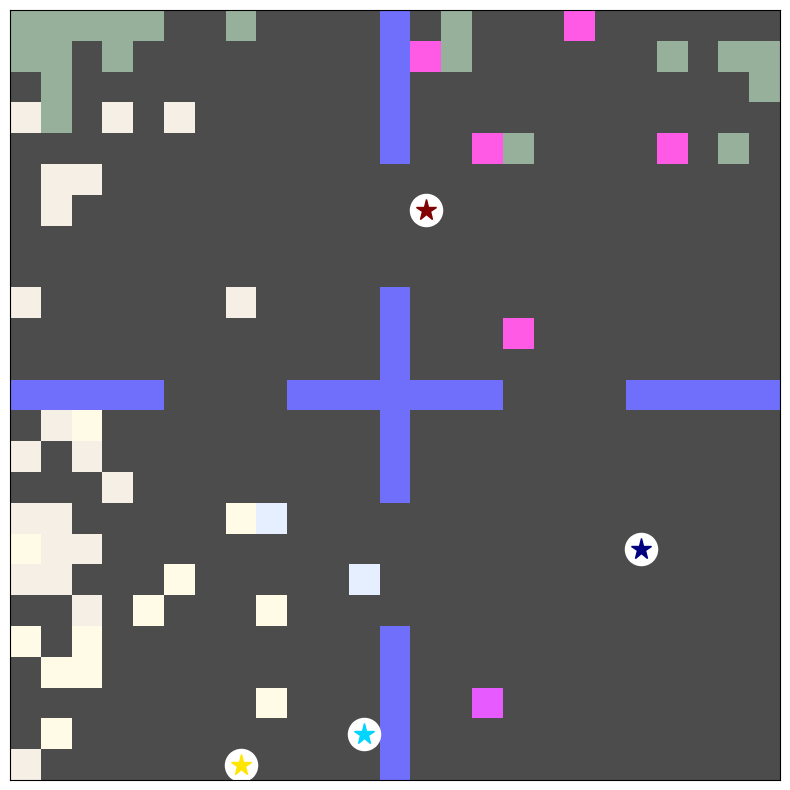

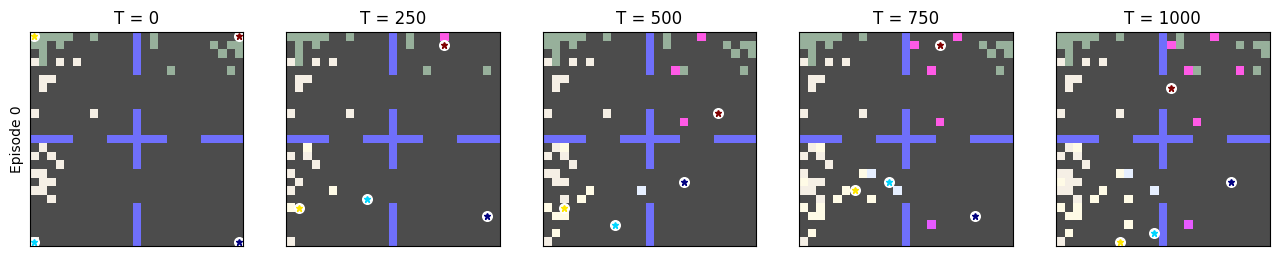

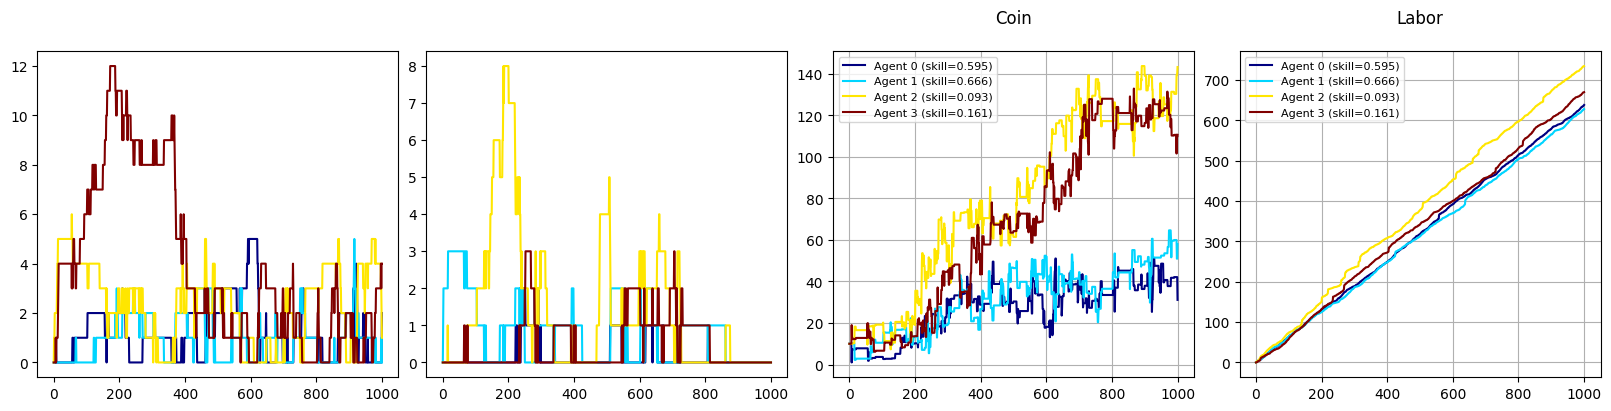

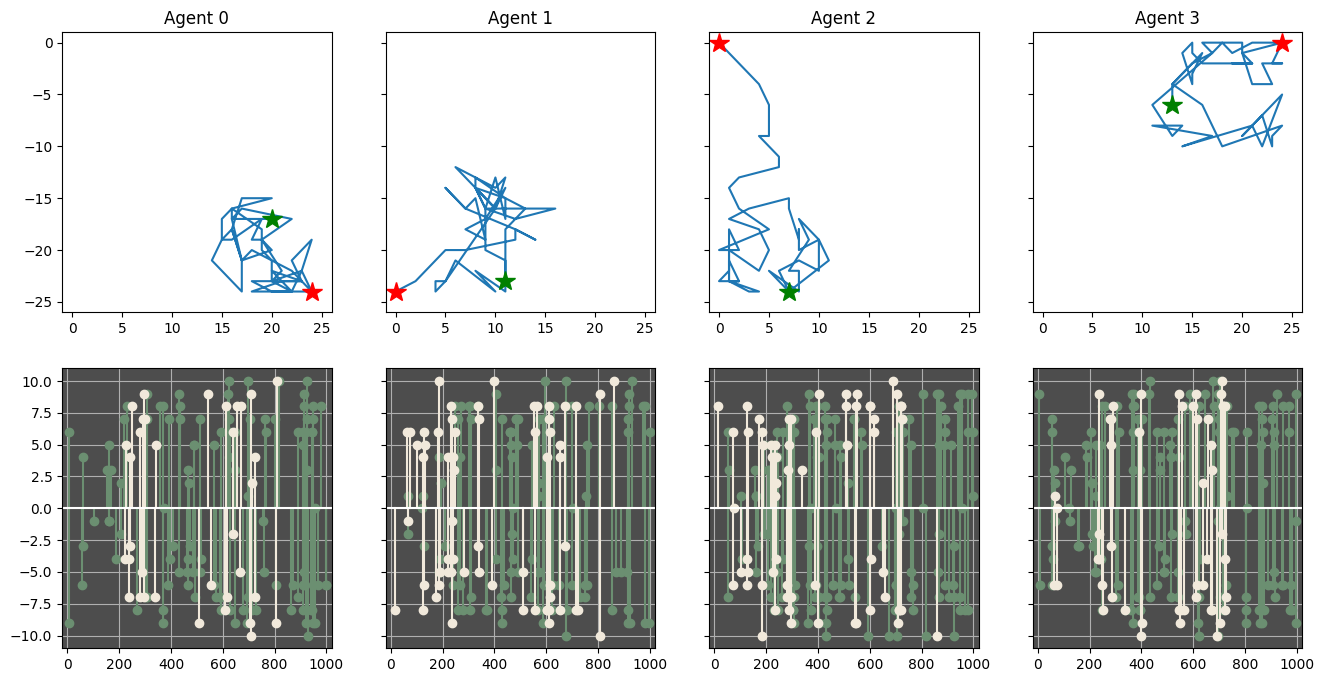

In [87]:
play_random_episode(env_p, plot_every=100, do_dense_logging=True)

# Grab the dense log from the env
dense_log = env_p.previous_episode_dense_log

plotting.breakdown(dense_log)

In [88]:
import numpy as np

def _split_flat_planner_mask(flat_mask, planner):
    """
    Split a flat 1-D planner action_mask into 7 submasks (one per bracket),
    using planner.action_dim to recover subspace boundaries.
    """
    subspaces = list(planner.action_dim.items())          # [(name, n_with_noop), ...]
    n_noopless = [n-1 for _, n in subspaces]              # model_wrapper masks omit NO-OP → n-1
    offsets = np.cumsum([0] + n_noopless[:-1])

    flat = np.asarray(flat_mask, dtype=float).ravel()
    parts = []
    for n, off in zip(n_noopless, offsets):
        parts.append(flat[off:off+n])   # shape n, entries 0/1 (allowed)
    return parts, n_noopless

def _planner_random_masked_action(p_obs, planner):
    """
    Choose non-zero indices per bracket given the planner observation mask.
    Works with both flat-1D masks (flatten_masks=True) or dict submasks.
    Returns a 7-list: [idx1..N, ..., idx1..N] (0=no-op never chosen here).
    """
    mask = p_obs.get("action_mask", None)
    if mask is None:
        # fallback: pick midrates (never no-op on tax-day)
        return _planner_midrate_action(planner)

    # Flat 1-D mask
    if isinstance(mask, (list, np.ndarray)):
        parts, n_noopless = _split_flat_planner_mask(mask, planner)
        chosen = []
        for part in parts:
            if part.sum() <= 0:  # no legal non-zeros
                chosen.append(0)
            else:
                probs = part / part.sum()
                # +1 to map [0..n-1] mask index → planner action index [1..n],
                # because planner uses 0 as no-op.
                chosen.append(int(np.random.choice(len(part), p=probs)) + 1)
        return chosen

    # Dict of submasks (uncommon if flatten_masks=True)
    if isinstance(mask, dict):
        flat = planner.flatten_masks(mask).astype(float) if hasattr(planner, "flatten_masks") else np.asarray(mask).ravel()
        parts, n_noopless = _split_flat_planner_mask(flat, planner)
        chosen = []
        for part in parts:
            if part.sum() <= 0:
                chosen.append(0)
            else:
                probs = part / part.sum()
                chosen.append(int(np.random.choice(len(part), p=probs)) + 1)
        return chosen

    # Fallback midrate
    return _planner_midrate_action(planner)

def _planner_midrate_action(planner):
    """Middle rate in each bracket (indices 1..N; 0=no-op)."""
    n_noopless = [n-1 for _, n in planner.action_dim.items()]
    return [max(1, n//2) for n in n_noopless]

In [89]:
def _summarize_taxes(env):
    tax = env.get_component("PeriodicBracketTax")
    period = tax.period

    total_rev = 0.0
    n_taxdays = 0
    n_taxdays_positive = 0
    eff_rates = []  # collect effective tax rates across agents and tax-days

    for idx, entry in enumerate(tax.taxes):
        if isinstance(entry, dict) and "schedule" in entry:  # a collection step
            n_taxdays += 1
            rev = 0.0
            for a in env.world.agents:
                k = str(a.idx)
                rev += float(entry[k]["tax_paid"])
                eff_rates.append(float(entry[k]["effective_rate"]))
            total_rev += rev
            if rev > 0:
                n_taxdays_positive += 1

    avg_eff_rate = float(np.mean(eff_rates)) if len(eff_rates) else 0.0
    print("\n=== TAX SUMMARY ===")
    print(f"period={period}, tax_days={n_taxdays}, tax_days_with_positive_revenue={n_taxdays_positive}")
    print(f"total_collected_revenue={total_rev:.3f}, avg_effective_tax_rate={avg_eff_rate:.3f}")
    print("metrics:", tax.get_metrics())

In [90]:
from ai_economist import foundation

def run_episode_agents_and_planner(env_config,
                                   planner_policy="random_masked",   # "random_masked" | "midrate"
                                   print_every=25,
                                   do_dense_logging=True,
                                   override_period=None,             # e.g., 10 for quicker collections
                                   plot_every=None):                 # optional: call do_plot every N steps
    """
    - Mobile agents act via sample_random_actions(env, obs)
    - Planner acts on tax day (mask fully open) using chosen policy
    - Logs every tax collection with per-agent incomes, taxes, lump-sum, and revenue
    - Returns: env (for dense_log/etc.)
    """
    # Optionally override PeriodicBracketTax.period for testing
    cfg = dict(env_config)
    if override_period is not None:
        comps = []
        for name, kwargs in cfg["components"]:
            if name == "PeriodicBracketTax":
                k2 = dict(kwargs)
                k2["period"] = int(override_period)
                comps.append((name, k2))
            else:
                comps.append((name, kwargs))
        cfg["components"] = comps

    # Build env
    env = foundation.make_env_instance(**cfg)
    obs = env.reset(force_dense_logging=do_dense_logging)
    tax = env.get_component("PeriodicBracketTax")
    planner = env.world.planner

    # For quick per-step coin delta sanity
    last_coin = {str(a.idx): a.total_endowment("Coin") for a in env.world.agents}

    # Helpers
    def _planner_action_for_taxday(p_obs):
        if planner_policy == "midrate":
            return _planner_midrate_action(planner)
        else:
            return _planner_random_masked_action(p_obs, planner)

    print("\n=== EPISODE START ===")
    print(f"episode_length={env.episode_length} | period={tax.period} | planner_policy={planner_policy}")

    # Main loop
    for t in range(1, env.episode_length + 1):
        # 1) Sample random actions for ALL entities (this includes planner too)
        actions = sample_random_actions(env, obs)

        # 2) Override ONLY the planner (to ensure correct tax-day behavior)
        p_obs = obs.get(planner.idx, {})
        p_mask = p_obs.get("action_mask", None)
        mask_sum = float(np.asarray(p_mask).sum()) if p_mask is not None else 0.0
        is_tax_day = (mask_sum >= 154.0 - 1e-6)   # robust to float jitter

        if is_tax_day:
            actions[planner.idx] = _planner_action_for_taxday(p_obs)
        else:
            # On non-tax days, planner has to no-op across bracket subspaces
            actions[planner.idx] = [0] * len(planner.action_dim)

        # 3) Step
        obs, rew, done, info = env.step(actions)

        # 4) Per-step sanity print
        if (print_every and (t % print_every == 0)) or tax.tax_cycle_pos == 2:
            now_coin = {str(a.idx): a.total_endowment("Coin") for a in env.world.agents}
            dcoin = {k: round(now_coin[k] - last_coin[k], 2) for k in now_coin.keys()}
            print(f"[t={t:4d}] pos={tax.tax_cycle_pos:3d}  Δcoin(step)={dcoin}")
            last_coin = now_coin

        # 5) If a tax collection happened on this step, log the full tax-day record
        #    The component pushes a dict to tax.taxes on collection steps; [] otherwise.
        if tax.taxes and isinstance(tax.taxes[-1], dict) and "schedule" in tax.taxes[-1]:
            td = tax.taxes[-1]
            # Compute revenue: sum of tax_paid across agents
            rev = 0.0
            for a in env.world.agents:
                rev += float(td[str(a.idx)]["tax_paid"])

            print("\n--- TAX COLLECTION ---")
            print("  schedule:", np.round(td["schedule"], 3))
            print("  cutoffs :", np.round(td["cutoffs"], 3))
            for a in env.world.agents:
                k = str(a.idx)
                rec = td[k]
                print(f"  agent {k}: income={rec['income']:.3f}  tax_paid={rec['tax_paid']:.3f}  eff_rate={rec['effective_rate']:.3f}")
            # Lump sum is same for all agents; read from any agent
            k0 = str(env.world.agents[0].idx)
            print(f"  lump_sum per agent: {td[k0]['lump_sum']:.3f}")
            print(f"  PERIOD REVENUE: {rev:.3f}\n")

        # 6) Optional plotting (your do_plot)
        if plot_every and ((t % plot_every) == 0):
            fig, ax = plt.subplots(1, 1, figsize=(8, 8))
            do_plot(env, ax, fig)
            plt.close(fig)

        if done["__all__"]:
            break

    print("=== EPISODE END ===")

    # Episode-level summary
    _summarize_taxes(env)
    return env

In [91]:
import matplotlib.pyplot as plt
import numpy as np

def plot_planner_action(env):
    """
    Plots the CURRENT marginal tax schedule (7 brackets) 
    and the revenue of the LAST tax day.
    
    Call this AFTER running an episode and after plotting.breakdown(dense_log).
    """

    tax = env.get_component("PeriodicBracketTax")

    # --- Get current marginal rates ---
    curr_rates = np.array(tax.curr_marginal_rates)   # shape (7,)
    bracket_labels = [f"{int(c):03d}" for c in tax.bracket_cutoffs]

    # --- Get the last tax-day revenue ---
    revenue = 0.0
    last_td = None
    for entry in reversed(tax.taxes):
        if isinstance(entry, dict) and "schedule" in entry:
            last_td = entry
            break

    if last_td is not None:
        revenue = sum(float(last_td[str(a.idx)]["tax_paid"]) for a in env.world.agents)
    else:
        revenue = 0.0

    # ---- Create the plot ----
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

    ax1.plot(bracket_labels, curr_rates, marker='o', linewidth=2, color='tab:blue')
    ax1.set_title("Current Marginal Tax Schedule & Last Tax-Day Revenue")
    ax1.set_xlabel("Tax Bracket (cutoff)")
    ax1.set_ylabel("Marginal Rate", color='tab:blue')
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)

    # Revenue as text on plot
    ax1.text(0.02, 0.92,
             f"Revenue (last tax-day): {revenue:.2f}",
             transform=ax1.transAxes,
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    plt.tight_layout()
    plt.show()

In [92]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tax_timeseries_single_bracket(env, bracket_index=0, title_prefix="Tax Time Series"):
    """
    Plots a time-series of:
      (1) marginal tax rate for ONE chosen bracket over tax-days
      (2) revenue per tax-day

    bracket_index: integer 0..6   (0='000', 1='009', ..., 6='510')
    """

    tax = env.get_component("PeriodicBracketTax")
    taxes = tax.taxes

    # Labels for bracket names (for legend/title)
    bracket_labels = [f"{int(c):03d}" for c in tax.bracket_cutoffs]

    # Storage
    t_points = []      # timesteps (1-based)
    rates = []         # single bracket rate per tax day
    revenues = []      # revenue per tax day

    for i, entry in enumerate(taxes):
        if isinstance(entry, dict) and "schedule" in entry:
            t_points.append(i + 1)
            schedule = np.array(entry["schedule"], dtype=float)
            rates.append(schedule[bracket_index])

            # compute revenue = sum of tax_paid across agents
            rev = sum(float(entry[str(a.idx)]["tax_paid"]) for a in env.world.agents)
            revenues.append(rev)

    if len(t_points) == 0:
        print("No tax-day entries found.")
        return

    # Convert to arrays
    t_points = np.array(t_points)
    rates = np.array(rates)
    revenues = np.array(revenues)

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # 1) Marginal tax rate (chosen bracket)
    axes[0].plot(t_points, rates, marker='o', linewidth=2, color='tab:blue')
    axes[0].set_title(f"{title_prefix}: Marginal Rate for Bracket {bracket_labels[bracket_index]}")
    axes[0].set_ylabel("marginal rate (0..1)")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, alpha=0.3)

    # 2) Revenue per tax day
    axes[1].plot(t_points, revenues, marker='s', linewidth=2, color='black')
    axes[1].set_title(f"{title_prefix}: Revenue per Tax Day")
    axes[1].set_ylabel("revenue")
    axes[1].set_xlabel("timestep (tax-day)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [93]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tax_timeseries(env, title_prefix="Tax Day Time Series"):
    """
    Time-series figure with:
      (1) marginal tax rates per bracket on each tax-day
      (2) revenue per tax-day

    Reads history from env.get_component("PeriodicBracketTax").taxes.
    X-axis = actual timesteps when collection occurred (index+1 in tax.taxes).
    """
    tax = env.get_component("PeriodicBracketTax")
    taxes = tax.taxes  # list; dict with "schedule" exists only on collection steps

    # Gather timesteps, schedules (7-length), and revenue per tax day
    t_points = []             # actual timesteps (1-based)
    schedules = []            # list of 7-length marginal schedules
    revenues = []             # scalar revenue per tax-day

    for i, entry in enumerate(taxes):
        if isinstance(entry, dict) and "schedule" in entry:
            t_points.append(i + 1)  # timestep of collection
            schedules.append(np.array(entry["schedule"], dtype=float))
            # revenue = sum of tax_paid across all mobile agents
            rev = 0.0
            for a in env.world.agents:
                k = str(a.idx)
                rev += float(entry[k]["tax_paid"])
            revenues.append(rev)

    if len(t_points) == 0:
        print("No tax-day entries found (no collections recorded).")
        return

    t_points = np.array(t_points)
    schedules = np.vstack(schedules)           # shape: (K taxdays, 7 brackets)
    revenues = np.array(revenues, dtype=float) # shape: (K,)

    bracket_labels = [f"{int(c):03d}" for c in tax.bracket_cutoffs]  # e.g. ['000','009','039','084','160','204','510']

    # --- PLOT ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # (1) Marginal tax schedule per bracket over tax days
    ax = axes[0]
    for b in range(schedules.shape[1]):
        ax.plot(t_points, schedules[:, b], marker='o', linewidth=2, label=f"bracket {bracket_labels[b]}")
    ax.set_title(f"{title_prefix}: Marginal Rates (per bracket)")
    ax.set_ylabel("marginal rate (0..1)")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", ncol=4, fontsize=9)

    # (2) Revenue per tax day
    ax2 = axes[1]
    ax2.plot(t_points, revenues, marker='s', linewidth=2, color="black")
    ax2.set_title(f"{title_prefix}: Revenue per Tax Day")
    ax2.set_xlabel("timestep (collection steps)")
    ax2.set_ylabel("revenue")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


=== EPISODE START ===
episode_length=1000 | period=10 | planner_policy=random_masked
[t=   1] pos=  2  Δcoin(step)={'0': 0.0, '1': 0.0, '2': 0.0, '3': 0.0}

--- TAX COLLECTION ---
  schedule: [0.6  0.   0.3  0.25 0.95 0.6  0.6 ]
  cutoffs : [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
  agent 0: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 1: income=4.000  tax_paid=2.400  eff_rate=0.600
  agent 2: income=-4.000  tax_paid=0.000  eff_rate=0.000
  agent 3: income=0.000  tax_paid=0.000  eff_rate=0.000
  lump_sum per agent: 0.600
  PERIOD REVENUE: 2.400

[t=  11] pos=  2  Δcoin(step)={'0': np.float64(0.6), '1': np.float64(2.2), '2': np.float64(-3.4), '3': np.float64(0.6)}

--- TAX COLLECTION ---
  schedule: [0.2  0.35 0.35 0.15 0.85 0.   0.45]
  cutoffs : [  0.      9.7    39.475  84.2   160.725 204.1   510.3  ]
  agent 0: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 1: income=0.000  tax_paid=0.000  eff_rate=0.000
  agent 2: income=0.000  tax_paid=0.000  eff_ra

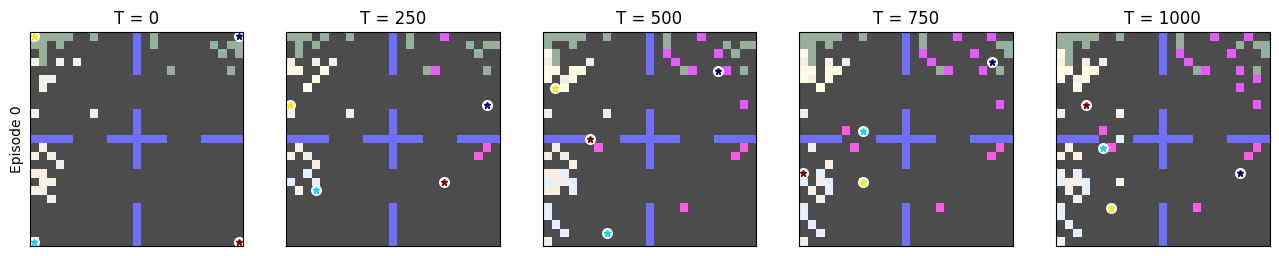

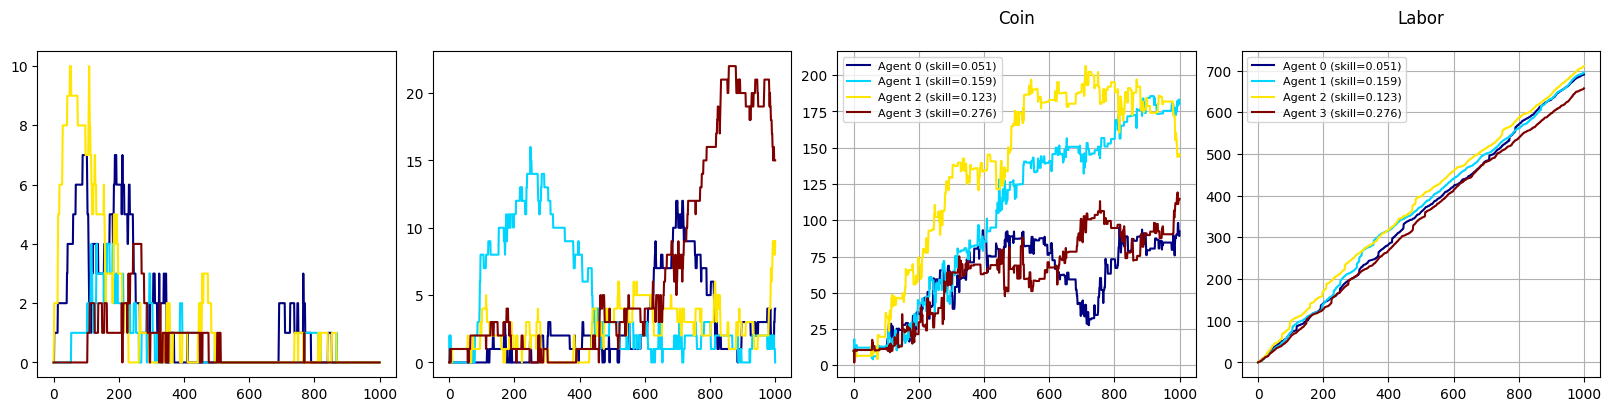

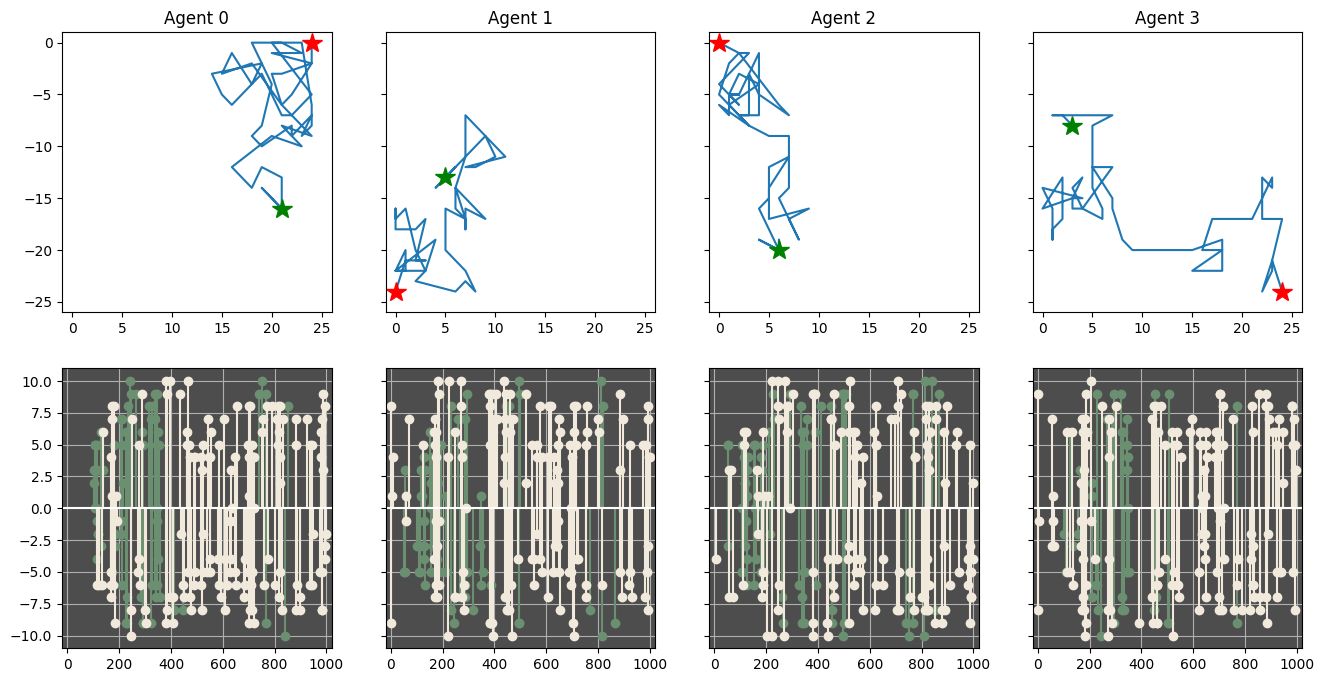

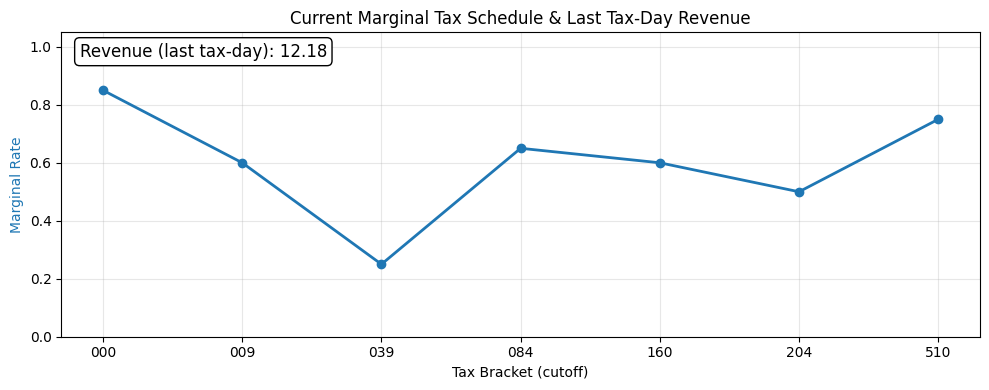

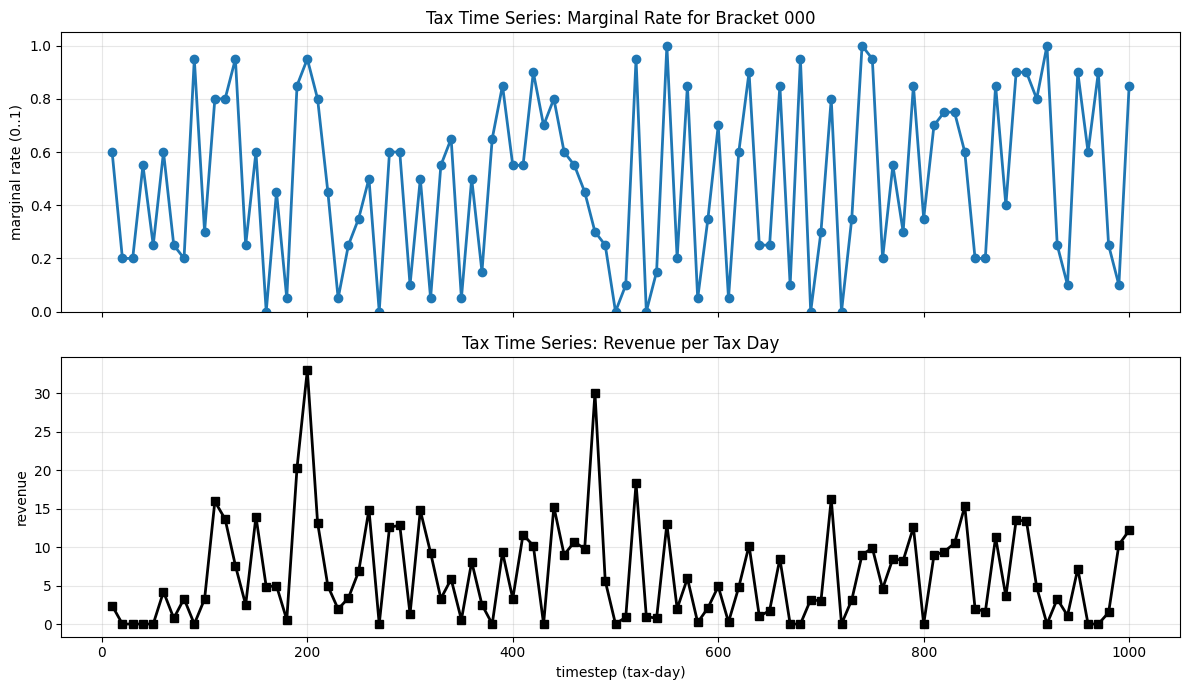

In [ ]:
env_out = run_episode_agents_and_planner(
    env_config=env_config_dict,
    planner_policy="random_masked",   # or "midrate"
    print_every=50,
    do_dense_logging=True,
    override_period=10,               # try 10 → revenue prints 10x more often
    plot_every=None
)

# If you want the post-hoc dense log visualization:
dense_log = env_out.previous_episode_dense_log
plotting.breakdown(dense_log)
plot_planner_action(env_out)
#plot_tax_timeseries(env_out)
plot_tax_timeseries_single_bracket(env_out, bracket_index=0)